# PostOffice Horizon IT Inquiry - Part 2 -(Jupyter Notebook-Local Environment)
# Data Cleaning, Word Error Rate, Named Entity Recogniion, Cross-pipeline Network Fragility Analysis and Relation Extraction Pilot

**Module:** BUSI 1783 
**Supervisor:** Guru Ramakrishnan
**Module Leader:** Dr. Srinidhi Vasudevan
**Student ID** 001479743 (May)

## Overview
The notebook builds on the transcripts produced in Part 1 ( Faster-Whisper, Assembly API, and offical inquiry transcripts. This notebook includes text cleaning, calculates Word Error Rate (WER) against official transcripts, extracts named entities in four categories, constructs undirected actor-system co-occurrence networkss, and measures structural fragility in information flow (bridges, articulation points, Burt's constraint, betwenness centrality).

Under the supervisor guidance, the frgaility analysis is now run on two independently constructed transcription pipelines (Assembly API and Faster Whisper) for the three sessions where both exist so that the consistency of fragility findings across pipelines can be tested directly.

Environment-Local Anaconda/Jupyter environment. Input- Raw and cleaned transcript files from Part 1

## Sections
1. Data setup
2. Name-correction table and entity dictionaries
3. Session configuration
4. Data cleaning and dual-pipeline WER (Day 143, 152 and 156)
5. WER comparison chart
6. Limited manual validation (spot-check) and scoping noted
7. Cleaning for Day 117 (Bates)- AssemblyAPI only
8. Comparative study (Infected Blood Inquiry)- WER only
9. Named Entity Recognition- primary pipeline (AssemblyAPI)
10. Named Entity Recognition- secondary pipeline (Faster-whisper) for cross-pipeline testing
11. NER quality-control checks
12. Entity summary tables
13. Network construction and fragility metrics (AssemblyAPI- bridges, articulation points, constraint, density
14. Network construction and fragility metrics (Faster-Whisper)
15. Cross-pipeline fragility comparison (Jaccard overlap, Speaman rank correlation)- answers RQ2
16. Combined network (all four sessions merged)
17. Gephi ecport
18. GitHUb Export package
19. Relation extraction (directed relations,Actor--->Event--->Actor chains)
20. Betweenness centrality (broker analysis)
21. Key entity mention counts
22. Co-occurrence heatmaps
23. Entity mention timelines
24. Summary
25. AI  declaration

## 1. Data Setup

In [2]:
# Imports and shared file 

import re, os
import jiwer
import spacy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import requests
from itertools import combinations
from collections import Counter, defaultdict
from scipy.stats import spearmanr

nlp = spacy.load("en_core_web_sm")

def load_text(path):
    with open(path, "r", encoding="utf-8", errors="replace") as f:
        return f.read()

def save_text(path, text):
    with open(path, "w", encoding="utf-8") as f:
        f.write(text)

def download_if_missing(path, url):
    """Downloads a file to `path` only if it doesn't already exist locally."""
    if os.path.exists(path):
        print(f"Already have: {path}")
        return True
    print(f"Downloading {path} ...")
    try:
        r = requests.get(url, timeout=30)
        r.raise_for_status()
        with open(path, "wb") as f:
            f.write(r.content)
        print(f"  Saved: {path} ({len(r.content)} bytes)")
        return True
    except Exception as e:
        print(f"  FAILED to download {path}: {e}")
        print(f"  If this link has expired, manually download from the Inquiry's hearing page "
              f"and save as '{path}' in this folder, then re-run this cell.")
        return False

def strip_fw_timestamps(text):
    return re.sub(r"\[\d+\.\d+s\s*->\s*\d+\.\d+s\]\s*", "", text)

def strip_official_formatting(text):
    text = text.replace("\r", " ").replace("\f", " ")
    text = re.sub(r"^\s*\d+\s+", "", text, flags=re.MULTILINE)
    text = re.sub(r"\b[A-Z]{2,}(?:\s[A-Z]{2,})*\s*:", " ", text)
    text = re.sub(r"\bQ\.\s*", " ", text)
    text = re.sub(r"\bA\.\s*", " ", text)
    return text

def normalise_for_wer(text):
    text = text.lower()
    text = re.sub(r"[^\w\s]", " ", text)
    return re.sub(r"\s+", " ", text).strip()

def count_mentions(text, name):
    return len(re.findall(re.escape(name), text, flags=re.IGNORECASE))

print("Setup complete. Working directory:", os.getcwd())


Setup complete. Working directory: /Users/maybranyaung


## 2. Shared Name-Correction Table and Entity Dictionaries
Used to standardize transcription errors and merge variant mentions of the same actors and systems.


In [3]:
NAME_CORRECTIONS = [
    (r"\b(Venald|Reynolds|Venables|Wells|Jonas|Meddows|Bennells|Meddles|Benals)\b", "Vennells"),
    (r"\bWarnton\b", "Warmington"),
    (r"\b(Veer|Bayh|Bloom)\b", "Beer"),
    (r"\bLeslie\s+Sewell\b", "Lesley Sewell"),
    (r"\bLesley\s+Soule\b", "Lesley Sewell"),
    (r"\b(Alwyn|Olwyn|Olwen|Olin|Owen)\s+Lyons\b", "Alwen Lyons"),
    (r"\bsecond\s+site\b", "Second Sight"),
    (r"\bSecond\s+Site\b", "Second Sight"),
    (r"\bSeema\s+Mishra\b", "Seema Misra"),
    (r"\bVerizon\b", "Horizon"),
    (r"\bE\s?POS(S)?\b", "EPOSS"),
    (r"\bRepost[e]?\b", "Riposte"),
    (r"\bPinnacle(s)?\b", "PinICL"),
    (r"\bCastle\s?ton\b", "Castleton"),
    (r"\bEsher\b", "Escher"),
]

def clean_transcript_text(text):
    cleaned = text
    for pattern, replacement in NAME_CORRECTIONS:
        cleaned = re.sub(pattern, replacement, cleaned, flags=re.IGNORECASE)
    return cleaned

ENTITY_NORMALISATION = {
    "second sight": "Second Sight", "sight": "Second Sight",
    "fujitsu": "Fujitsu", "horizon": "Horizon",
    "the post office": "Post Office", "post office": "Post Office",
    "vennells": "Vennells", "ms vennells": "Vennells", "paula": "Vennells",
    "mr beer": "Beer", "beer": "Beer", "jason beer": "Beer",
    "lesley sewell": "Lesley Sewell", "lesley": "Lesley Sewell",
    "alwen lyons": "Alwen Lyons", "alwyn": "Alwen Lyons",
    "seema misra": "Seema Misra",
    "susan crichton": "Susan Crichton", "susan": "Susan Crichton",
    "ron warmington": "Ron Warmington", "warmington": "Ron Warmington",
    "ian henderson": "Ian Henderson", "henderson": "Ian Henderson",
    "alice perkins": "Alice Perkins",
    "james arbuthnot": "James Arbuthnot", "arbuthnot": "James Arbuthnot",
    "bates": "Alan Bates", "alan bates": "Alan Bates",
    "jenkins": "Gareth Jenkins", "gareth jenkins": "Gareth Jenkins",
    "kay": "Kay Lynell", "kay lynell": "Kay Lynell",
    "microsoft exchange": "Microsoft Exchange", "the microsoft exchange": "Microsoft Exchange",
}

KNOWN_PEOPLE = {
    "Vennells", "Beer", "Susan Crichton", "Alice Perkins", "Alan Bates",
    "Lesley Sewell", "Alwen Lyons", "Seema Misra", "James Arbuthnot",
    "Ron Warmington", "Ian Henderson", "Gareth Jenkins", "Kay Lynell",
}

KNOWN_ORGS = ["Post Office", "Second Sight", "Deloitte", "Fujitsu", "CCRC",
              "Justice for Subpostmasters Alliance"]

TECHNICAL_SYSTEMS = ["Horizon", "Horizon Online", "Legacy Horizon", "the system",
                     "EPOSS", "Riposte", "PinICL", "PEAK", "Microsoft Exchange"]

EVENTS_ISSUES = ["bug", "bugs", "error", "errors", "mismatch", "discrepancy",
                  "suspense account", "mediation scheme", "shortfall", "shortfalls",
                  "defect", "defects", "glitch", "audit"]

def normalise_entity(text):
    key = text.strip()
    key = re.sub(r"[\u2019\'\u2018]s$", "", key)
    key = key.lower().strip()
    return ENTITY_NORMALISATION.get(key, text.strip())

FORCED_CATEGORY = {
    "Second Sight": "Organisation", "Horizon": "Technical System",
    "Horizon Online": "Technical System", "Legacy Horizon": "Technical System",
    "the system": "Technical System", "EPOSS": "Technical System",
    "Riposte": "Technical System", "PinICL": "Technical System",
    "Microsoft Exchange": "Technical System",
}
WORD_VARIANT_MERGE = {
    "bugs": "bug", "defects": "defect", "errors": "error",
    "shortfalls": "shortfall", "glitches": "glitch",
}


## 3. Session Configuration
File paths,  cutting off the 6 hour (AM+PM) session into 3 hour session and the comparative study configuration for each hearing day. 

In [4]:
SESSIONS = {
    "Day143": {
        "fw_path": "FW_Vennells_Day143.txt",
        "api_path": "API_Vennells_Day143.txt",
        "official_path": "YT_Vennells_Day143.txt",
        "official_url": "https://www.postofficehorizoninquiry.org.uk/sites/default/files/2024-05/INQ00001152.txt",
        "cutoff_end": 180904,     # AM session
        "anchor": "Vennells",
        "has_fw": True, "has_official": True,
    },
    "Day152": {
        "fw_path": "FW_Warmington_Day152.txt",
        "api_path": "API_Warmington_Day152.txt",
        "official_path": "YT_Warmington_Day152.txt",
        "official_url": "https://www.postofficehorizoninquiry.org.uk/file/3680/download?token=AkNC2YSu",
        "cutoff_start": 180898,   # PM session
        "anchor": "Ron Warmington",
        "has_fw": True, "has_official": True,
    },
    "Day156": {
        "fw_path": "FW_Jenkins_Day156.txt",
        "api_path": "API_Jenkins_Day156.txt",
        "official_path": "YT_Jenkins_Day156.txt",
        "official_url": "https://www.postofficehorizoninquiry.org.uk/file/3804/download?token=aaVLkHR_",
        "cutoff_end": 215466,     # AM session
        "anchor": "Gareth Jenkins",
        "has_fw": True, "has_official": True,
    },
    "Day117": {
        "api_path": "API_Bates_Day117_AM.txt",
        "anchor": "Alan Bates",
        "has_fw": False, "has_official": False,
    },
}

# Sessions with a Faster-Whisper transcript available for cross-pipeline comparison
FW_SESSIONS = [s for s, cfg in SESSIONS.items() if cfg.get("has_fw")]

COMPARATIVE = {
    "api_path": "Comparative study- Blood Scandal UK.txt",
    "official_path": "OFFICIAL_Sunak_InfectedBlood.pdf",
    "official_url": "https://www.infectedbloodinquiry.org.uk/sites/default/files/documents/"
                     "Transcript%20-%20London%20-%20Wednesday%2026%20July%202023%20-%20(Rishi%20Sunak)_0.pdf",
    "anchor": "Rishi Sunak",
}

print("Sessions configured:", list(SESSIONS.keys()))
print("Sessions with Faster-Whisper transcripts:", FW_SESSIONS)


Sessions configured: ['Day143', 'Day152', 'Day156', 'Day117']
Sessions with Faster-Whisper transcripts: ['Day143', 'Day152', 'Day156']


## 4. Data Cleaning and Dual-Pipeline Word Error Rate- Day 143, 152 and 156
Timestamps, speakerlabels, and line numbers are stripped so they don't affect WER

In [5]:
wer_results_all = {}
cleaned_texts = {}
for session in ["Day143", "Day152", "Day156"]:
    cfg = SESSIONS[session]
    print(f"\n{'='*60}\n{session}\n{'='*60}")

    download_if_missing(cfg["official_path"], cfg["official_url"])

    official_full = load_text(cfg["official_path"])
    if "cutoff_end" in cfg:
        official_scoped = official_full[:cfg["cutoff_end"]]
    else:
        official_scoped = official_full[cfg["cutoff_start"]:]
    official_text = strip_official_formatting(official_scoped)

    fw_raw = strip_fw_timestamps(load_text(cfg["fw_path"]))
    api_raw = load_text(cfg["api_path"])

    fw_clean = clean_transcript_text(fw_raw)
    api_clean = clean_transcript_text(api_raw)

    save_text(f"FW_{session}_CLEANED.txt", fw_clean)
    save_text(f"API_{session}_CLEANED.txt", api_clean)

    official_norm = normalise_for_wer(official_text)
    wer_results = {
        "Faster-Whisper (raw)":     jiwer.wer(official_norm, normalise_for_wer(fw_raw)),
        "Faster-Whisper (cleaned)": jiwer.wer(official_norm, normalise_for_wer(fw_clean)),
        "AssemblyAI (raw)":         jiwer.wer(official_norm, normalise_for_wer(api_raw)),
        "AssemblyAI (cleaned)":     jiwer.wer(official_norm, normalise_for_wer(api_clean)),
    }
    for label, w in wer_results.items():
        print(f"  {label:28s} WER = {w*100:6.2f}%")

    wer_results_all[session] = wer_results
    cleaned_texts[session] = {"api": api_clean, "fw": fw_clean, "official": official_text}

print("\nSaved *_CLEANED.txt files locally for Day143, Day152, Day156.")



Day143
Already have: YT_Vennells_Day143.txt
  Faster-Whisper (raw)         WER =   7.09%
  Faster-Whisper (cleaned)     WER =   6.71%
  AssemblyAI (raw)             WER =   6.01%
  AssemblyAI (cleaned)         WER =   5.82%

Day152
Already have: YT_Warmington_Day152.txt
  Faster-Whisper (raw)         WER =   8.17%
  Faster-Whisper (cleaned)     WER =   8.13%
  AssemblyAI (raw)             WER =   7.22%
  AssemblyAI (cleaned)         WER =   7.19%

Day156
Already have: YT_Jenkins_Day156.txt
  Faster-Whisper (raw)         WER =   7.38%
  Faster-Whisper (cleaned)     WER =   7.20%
  AssemblyAI (raw)             WER =   7.01%
  AssemblyAI (cleaned)         WER =   6.88%

Saved *_CLEANED.txt files locally for Day143, Day152, Day156.


## 5. WER Comparison Chart- Day 143, 152, 156

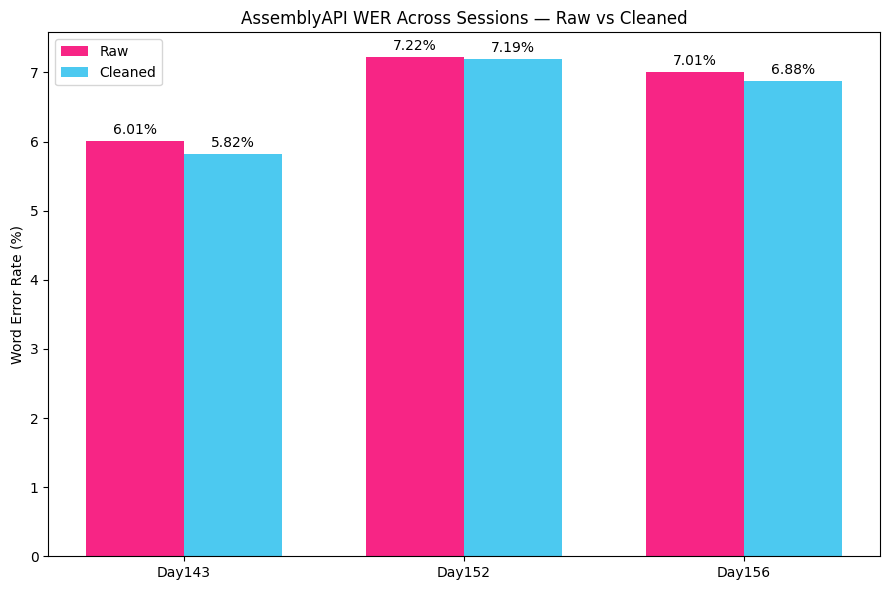

Saved: wer_comparison_all_sessions.png


In [6]:
sessions_with_wer = ["Day143", "Day152", "Day156"]
raw_wer = [wer_results_all[s]["AssemblyAI (raw)"] * 100 for s in sessions_with_wer]
clean_wer = [wer_results_all[s]["AssemblyAI (cleaned)"] * 100 for s in sessions_with_wer]

x = np.arange(len(sessions_with_wer))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 6))
bars1 = ax.bar(x - width/2, raw_wer, width, label="Raw", color="#F72585")
bars2 = ax.bar(x + width/2, clean_wer, width, label="Cleaned", color="#4CC9F0")
ax.set_ylabel("Word Error Rate (%)")
ax.set_title("AssemblyAPI WER Across Sessions — Raw vs Cleaned")
ax.set_xticks(x)
ax.set_xticklabels(sessions_with_wer)
ax.legend()
ax.bar_label(bars1, fmt="%.2f%%", padding=3)
ax.bar_label(bars2, fmt="%.2f%%", padding=3)
plt.tight_layout()
plt.savefig("wer_comparison_all_sessions.png", dpi=200, facecolor="white")
plt.show()
print("Saved: wer_comparison_all_sessions.png")


## 6 Limited manual validation (30 seconds *3 sessions from Day 143) 

3 short (30 second) slices were conducted from the original hearing audio from Youtube.
Each slice was listened to and transcribed manually by the researcher with human ears.
These manual notes were then compared informally with the Faster-Whisper and Assembly AI output as a small human check on transcription quality.

( Manual transcript- results)

 ## First session (Day 143) - 00:20-02:30 
 
Good morning, Mr Vennells
Yesterday, aside from the seven general topics that I dealt
with in the morning, we addressed two issues of substance uh.
One was the complaints made by Sub postMasters and others
about bugs, errors and defects.
And then secondly, we looked at remote access in the Afternoon
ms
Can I turn to my third topic of substance then which is the second sight investigation
and the complaint and mediation scheme
I ‘d like first to look at the process by which second sight was chosen and Deloitte
were not to conduct an investigation
And can we look please at poll 0180209 come up on the screen for you and if we
look at fourth of the page there an email from Simon Baker you’re not on this chain
Uh to Susan Crichton and Lesley J Sewell of the 6th of June 2012 and he says
Susan Lesley attached is Ron’s proposal
my view is that we make it clear to Alice and Paula the distinction between the work
Ron is proposing brackets an independent review of past cases and the Horizon
forensic audit the Deloitte proposal and put it on the agenda to discuss tomorrow
which would be the 7th of June

## Second session -1:27:02 to  1:28:33


Specifically the post office legal team and its lawyers going back and looking at all the cases that wasn't the work that was in place why I would why wasn't it put in place here you're suggesting that the post office itself through external lawyers proactively review all cases of false account going back up to a decade yes and you've I think accepted that that would be the um the fair and proper thing to do why didn't the proper and fair thing to do get done I can't remember whether you have any further documentation that would see what answer I got to that my come to the answers yes the the narrow answers and essentially we're going to find out that Mark Davis the pr guy said it's very dangerous I I don't remember that I was asking the question to do this work the right way and my understanding and acceptance of what was proposed which was accepted by the MPs and everybody else involved was that the mediation scheme was the right way through I think we see other documentation that see cases go to the CCRC there is documentation that that says cases can't be resolved through mediation in the scheme and they would need to go through the court of appeal um the fact I can recall those I suspect there was a wider discussion around this at some stage

## Third Session-  2:39 :59  to 2:41:29

Can you see this is an email to you and others from Alwyn Lyons read the James brief and she says Paula the only thing that is not in the brief for James is our move away from quote there are no bugs in Horizon to  there are known bugs in every computer system this size but they are found and put right and no sub postmaster is disadvantaged by them it would be good to be able to go on and say or has been success uh wrongfully suspended or Prosecuted Did this represent a move a shift in position preemptively

Before the second sight report from there are no bugs in Horizon to the then altered position that's set out by   Alwyn Lyons  it was so firstly I don't recall and I think Alwyn said this on Tuesday as well that there had been um a line as it were that there were no bugs in Horizon I I don't remember and I haven't seen it anywhere as being used but but it would be  completely right for the post office if that was a line that it had used to correct it I mean if that's right it wouldn't have been done preemptively  because of the second sight report it would just have been done because it was the right thing to do if that's right



## 7. Data Cleaning for Day 117 (Bates)- AssemblyAPI only
Assembly API is used as the only pipeline for this session (no official transcript exist for WER comparison and no Faster-Whisper transcript was produced.

In [7]:
for session in ["Day117"]:
    cfg = SESSIONS[session]
    api_raw = load_text(cfg["api_path"])
    api_clean = clean_transcript_text(api_raw)
    save_text(f"API_{session}_CLEANED.txt", api_clean)
    cleaned_texts[session] = {"api": api_clean, "fw": None, "official": None}
    print(f"Saved: API_{session}_CLEANED.txt")


Saved: API_Day117_CLEANED.txt


## 8. Comparative Study (Rishi Sunak, Infected Blood Inquiry)- WER only
This short comparative study tests whether the same WER pipeline can be applied to different public inquiry testimony without any Post-Office specific cleaning rules.


In [8]:
!pip install pdfplumber --quiet



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [9]:
def extract_pdf_text(path):
    try:
        import pdfplumber
    except ModuleNotFoundError:
        print("pdfplumber is not installed. Run: !pip install pdfplumber")
        return None
    text_parts = []
    with pdfplumber.open(path) as pdf:
        for page in pdf.pages:
            page_text = page.extract_text()
            if page_text:
                text_parts.append(page_text)
    return "\n".join(text_parts)

if not os.path.exists(COMPARATIVE["official_path"]):
    print(f"Official PDF not found: {COMPARATIVE['official_path']}")
    print("Download it from:")
    print(COMPARATIVE["official_url"])
    print("and save it with the exact name above.")
elif not os.path.exists(COMPARATIVE["api_path"]):
    print(f"API transcript not found: {COMPARATIVE['api_path']}")
else:
    official_raw = extract_pdf_text(COMPARATIVE["official_path"])
    if official_raw is None:
        print("Could not extract text from the PDF.")
    else:
        official_text = strip_official_formatting(official_raw)
        api_raw = load_text(COMPARATIVE["api_path"])

        wer = jiwer.wer(normalise_for_wer(official_text), normalise_for_wer(api_raw))

        print("=" * 60)
        print(f"Comparative Study (Rishi Sunak) — AssemblyAI (raw) WER = {wer*100:.2f}%")
        print("=" * 60)
        print("\nNote: This is RAW WER only. No NER or network analysis is performed on this session.")


Comparative Study (Rishi Sunak) — AssemblyAI (raw) WER = 93.52%

Note: This is RAW WER only. No NER or network analysis is performed on this session.


## 9. Named Entity Recognition- Primary Pipeline (AssemblyAPI)
Extracts and classifies entities (Individuals, Organisation, Technical System, Event/Issue) from the cleaned AssemblyAPI transcripts for Day 143,152, 156 and 117,
using spaCY and keyword rules. AssemblyAPI is used as the primary pipeline for all downstream NER/Network analysis.

In [10]:
def find_keyword_matches(text_with_sents, keyword_list, category_label):
    results = []
    for i, sent_text in text_with_sents:
        for kw in keyword_list:
            if re.search(r"\b" + re.escape(kw) + r"\b", sent_text, re.IGNORECASE):
                results.append({
                    "sentence_index": i, "entity_raw": kw,
                    "entity_normalised": normalise_entity(kw),
                    "category": category_label, "sentence_text": sent_text.strip(),
                })
    return results

def extract_all_categories(text):
    doc = nlp(text)
    sentences = list(doc.sents)
    sent_spans = [(i, s.start_char, s.end_char) for i, s in enumerate(sentences)]

    def find_sentence_index(char_pos):
        for i, start, end in sent_spans:
            if start <= char_pos < end:
                return i
        return -1

    known_tech_lower = {t.lower() for t in TECHNICAL_SYSTEMS}
    known_orgs_lower = {o.lower() for o in KNOWN_ORGS}

    results = []
    for ent in doc.ents:
        if ent.label_ not in ("PERSON", "ORG"):
            continue
        sent_idx = find_sentence_index(ent.start_char)
        norm = normalise_entity(ent.text)
        norm_lower = norm.lower()

        if norm_lower in known_tech_lower:
            category = "Technical System"
        elif norm_lower in known_orgs_lower:
            category = "Organisation"
        elif ent.label_ == "PERSON" or norm in KNOWN_PEOPLE:
            category = "Individual"
        else:
            category = "Organisation"

        results.append({
            "sentence_index": sent_idx, "entity_raw": ent.text,
            "entity_normalised": norm, "category": category,
            "sentence_text": sentences[sent_idx].text.strip() if sent_idx >= 0 else "",
        })

    sents_list = [(i, s.text) for i, s in enumerate(sentences)]
    results += find_keyword_matches(sents_list, KNOWN_ORGS, "Organisation")
    results += find_keyword_matches(sents_list, TECHNICAL_SYSTEMS, "Technical System")
    results += find_keyword_matches(sents_list, EVENTS_ISSUES, "Event/Issue")

    df = pd.DataFrame(results)
    df = df.drop_duplicates(subset=["sentence_index", "entity_normalised", "category"])
    return df

def apply_fixes(df):
    df = df.copy()
    df["category"] = df.apply(
        lambda row: FORCED_CATEGORY.get(row["entity_normalised"], row["category"]), axis=1)
    df["entity_normalised"] = df["entity_normalised"].apply(
        lambda x: WORD_VARIANT_MERGE.get(x.lower(), x) if x.lower() in WORD_VARIANT_MERGE else x)
    df = df.drop_duplicates(subset=["sentence_index", "entity_normalised", "category"])
    return df

entities_dfs = {}
for session in SESSIONS:
    print(f"Extracting NER (AssemblyAI) — {session}...")
    df = extract_all_categories(cleaned_texts[session]["api"])
    df = apply_fixes(df)
    df.to_csv(f"api_entities_{session}.csv", index=False)
    entities_dfs[session] = df
    print(f"  {len(df)} mentions saved to api_entities_{session}.csv")


Extracting NER (AssemblyAI) — Day143...
  792 mentions saved to api_entities_Day143.csv
Extracting NER (AssemblyAI) — Day152...
  551 mentions saved to api_entities_Day152.csv
Extracting NER (AssemblyAI) — Day156...
  769 mentions saved to api_entities_Day156.csv
Extracting NER (AssemblyAI) — Day117...
  549 mentions saved to api_entities_Day117.csv


## 10 Named entity Recognition-Secondary Pipeline (Faster-Whisper)
The same extraction functions are applied to the FW cleaned transcripts for Day 143,152, 156  for testing Research Question 2 - to find network fragility findings hold consistently across independently constructed transcription pipelines- since that comparison is impossible if only one pipeline ever reaches the network phase.

In [11]:
fw_entities_dfs = {}
for session in FW_SESSIONS:  # Day143, Day152, Day156
    print(f"Extracting NER (Faster-Whisper) — {session}...")
    df = extract_all_categories(cleaned_texts[session]["fw"])
    df = apply_fixes(df)
    df.to_csv(f"fw_entities_{session}.csv", index=False)
    fw_entities_dfs[session] = df
    print(f"  {len(df)} mentions saved to fw_entities_{session}.csv")


Extracting NER (Faster-Whisper) — Day143...
  765 mentions saved to fw_entities_Day143.csv
Extracting NER (Faster-Whisper) — Day152...
  521 mentions saved to fw_entities_Day152.csv
Extracting NER (Faster-Whisper) — Day156...
  725 mentions saved to fw_entities_Day156.csv


## 11. NER Quality-Control Checks
Run on the primary (Assembly API) entity tables as the same checks can be re-run on 'fw_entities_dfs' if needed.

In [12]:
# Sanity check: no entity split across categories
for session, df in entities_dfs.items():
    for entity in ["Horizon", "Second Sight", "bug"]:
        cats = df[df["entity_normalised"] == entity]["category"].unique()
        if len(cats) > 1:
            print(f"WARNING — {session}: '{entity}' still split across {list(cats)}")
        elif len(cats) == 1:
            print(f"OK — {session}: '{entity}' -> {cats[0]}")


OK — Day143: 'Horizon' -> Technical System
OK — Day143: 'Second Sight' -> Organisation
OK — Day143: 'bug' -> Event/Issue
OK — Day152: 'Horizon' -> Technical System
OK — Day152: 'Second Sight' -> Organisation
OK — Day152: 'bug' -> Event/Issue
OK — Day156: 'Horizon' -> Technical System
OK — Day156: 'bug' -> Event/Issue
OK — Day117: 'Horizon' -> Technical System
OK — Day117: 'bug' -> Event/Issue


In [13]:
def qa_check(df, session_name):
    print(f"\n--- QA: {session_name} ---")

    nulls = df.isnull().sum()
    if nulls.sum() > 0:
        print("Missing values:\n", nulls[nulls > 0])

    bad_idx = (df["sentence_index"] == -1).sum()
    if bad_idx > 0:
        print(f"WARNING: {bad_idx} rows with unmapped sentence_index (-1)")

    dupes = df.duplicated(subset=["sentence_index", "entity_normalised", "category"]).sum()
    if dupes > 0:
        print(f"WARNING: {dupes} duplicate rows still present")

    junk = df[df["entity_normalised"].str.len() <= 2]
    if len(junk) > 0:
        print(f"WARNING: {len(junk)} suspiciously short entities:\n", junk["entity_normalised"].unique())

    print("Category counts:\n", df["category"].value_counts())

    if nulls.sum() == 0 and bad_idx == 0 and dupes == 0 and len(junk) == 0:
        print("Clean")

for session, df in entities_dfs.items():
    qa_check(df, session)

combined = pd.concat([df.assign(session=s) for s, df in entities_dfs.items()], ignore_index=True)
inconsistent = combined.groupby("entity_normalised")["category"].nunique()
inconsistent = inconsistent[inconsistent > 1]
if len(inconsistent) > 0:
    print("\nWARNING — entities with inconsistent categories across sessions:")
    print(inconsistent)
else:
    print("\nAll entities have consistent categories across sessions")



--- QA: Day143 ---
 <ArrowStringArray>
['AB', 'AG']
Length: 2, dtype: str
Category counts:
 category
Organisation        339
Individual          267
Event/Issue          97
Technical System     89
Name: count, dtype: int64

--- QA: Day152 ---
 <ArrowStringArray>
['Jo', 'TC']
Length: 2, dtype: str
Category counts:
 category
Individual          237
Organisation        222
Event/Issue          59
Technical System     33
Name: count, dtype: int64

--- QA: Day156 ---
 <ArrowStringArray>
['AP']
Length: 1, dtype: str
Category counts:
 category
Organisation        254
Individual          212
Technical System    188
Event/Issue         115
Name: count, dtype: int64

--- QA: Day117 ---
Category counts:
 category
Organisation        294
Individual          111
Technical System    105
Event/Issue          39
Name: count, dtype: int64
Clean

WARNING — entities with inconsistent categories across sessions:
entity_normalised
Alice            2
Anne             2
COVID            2
Castleton        2

In [14]:
# Manual near-duplicate entity check
all_entities = sorted(combined["entity_normalised"].unique())
near_dupes = []
for i, a in enumerate(all_entities):
    for b in all_entities[i+1:]:
        a_low, b_low = a.lower(), b.lower()
        if a_low != b_low and (a_low in b_low or b_low in a_low):
            near_dupes.append((a, b))

print(f"Found {len(near_dupes)} candidate near-duplicate pairs:")
for a, b in near_dupes:
    print(f"  '{a}'  <->  '{b}'")


Found 293 candidate near-duplicate pairs:
  'AB'  <->  'Probably'
  'AG'  <->  'Benefits Agency'
  'AG'  <->  'Head of Fraud Management'
  'AG'  <->  'ITL Management'
  'AG'  <->  'Magistrates' Court'
  'AG'  <->  'Paragraph 58'
  'AG'  <->  'Paragraphs 45'
  'AG'  <->  'Peter Savage'
  'AG'  <->  'Savage'
  'AG'  <->  'the Benefits Agency'
  'AP'  <->  'API'
  'AP'  <->  'CAPTCHA'
  'AP'  <->  'GE Capital'
  'AP'  <->  'Paragraph 58'
  'AP'  <->  'Paragraphs 45'
  'AP'  <->  'SAP'
  'AP'  <->  'the Court of Appeal'
  'AP'  <->  'the Court of Appeal Criminal Division'
  'API'  <->  'GE Capital'
  'Al Cameron'  <->  'Cameron'
  'Al Cameron'  <->  'Ron'
  'Alan'  <->  'Alan Bates'
  'Alan'  <->  'Alan Bates''
  'Alan'  <->  'Alan Jones'
  'Alan'  <->  'Alan Layton'
  'Alan'  <->  'Alan Ward'
  'Alan Bates'  <->  'Alan Bates''
  'Alan Jones'  <->  'Jo'
  'Alan Jones'  <->  'Jones'
  'Alice'  <->  'Alice Perkins'
  'Alliance'  <->  'Ian'
  'Amanda Peacock'  <->  'NDA'
  'Andrew'  <->  'And

## 12. Entity Summary Tables- Top mentions per Category per session

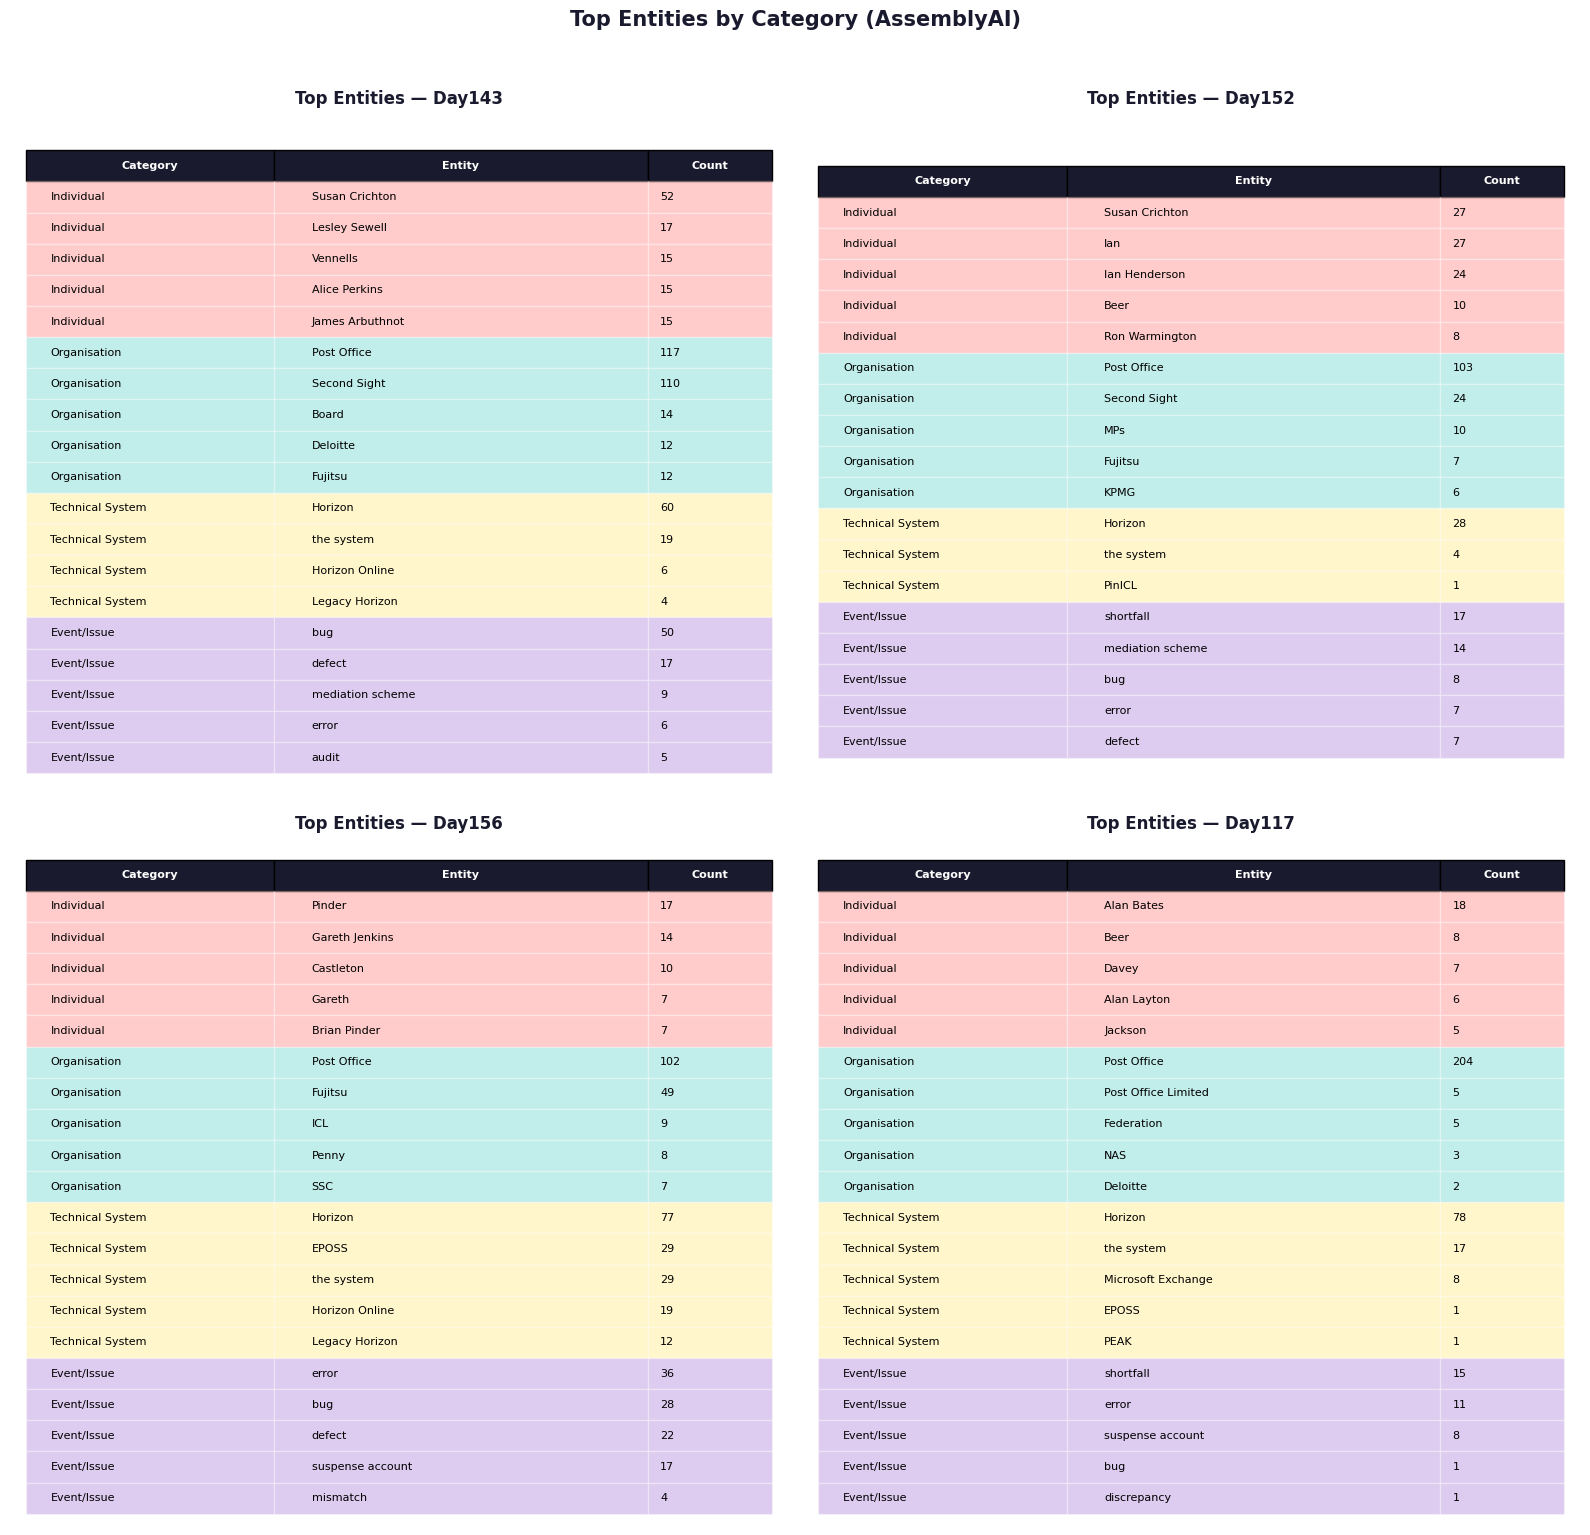

Saved: ner_table_all_days_side_by_side.png


In [15]:
CATEGORY_COLOURS = {
    "Individual":        "#FF6B6B",
    "Organisation":      "#4ECDC4",
    "Technical System":  "#FFE66D",
    "Event/Issue":       "#A06CD5",
}
HEADER_COLOUR = "#1A1A2E"

def build_top_entities_table(df, top_n=5):
    rows = []
    for cat in CATEGORY_COLOURS:
        subset = df[df["category"] == cat]
        top = Counter(subset["entity_normalised"]).most_common(top_n)
        for name, count in top:
            rows.append({"Category": cat, "Entity": name, "Count": count})
    return pd.DataFrame(rows)

def draw_colour_table(ax, table_df, title):
    ax.axis("off")
    ax.set_title(title, fontsize=12, fontweight="bold", pad=14, color="#1A1A2E")  # pad 10 -> 14
    cell_data = table_df[["Category", "Entity", "Count"]].values.tolist()
    tbl = ax.table(
        cellText=cell_data, colLabels=["Category", "Entity", "Count"],
        cellLoc="left", loc="center", colWidths=[0.32, 0.48, 0.16]
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(8)
    tbl.scale(1, 1.45)
    for j in range(3):
        tbl[0, j].set_facecolor(HEADER_COLOUR)
        tbl[0, j].set_text_props(color="white", fontweight="bold")
    for i, row in enumerate(cell_data, start=1):
        colour = CATEGORY_COLOURS.get(row[0], "#EEEEEE")
        for j in range(3):
            tbl[i, j].set_facecolor(colour)
            tbl[i, j].set_alpha(0.35)
            tbl[i, j].set_edgecolor("white")

sessions = list(entities_dfs.keys())
fig, axes = plt.subplots(2, 2, figsize=(16, 15))    # 12 -> 15
axes = axes.flatten()
for ax, session in zip(axes, sessions):
    table = build_top_entities_table(entities_dfs[session], top_n=5)
    draw_colour_table(ax, table, f"Top Entities — {session}")
fig.suptitle("Top Entities by Category (AssemblyAI)", fontsize=15,
             fontweight="bold", color="#1A1A2E", y=1.02)
plt.subplots_adjust(hspace=0.6, wspace=0.25)         # new line
plt.tight_layout()
plt.savefig("ner_table_all_days_side_by_side.png", dpi=200, facecolor="white", bbox_inches="tight")
plt.show()
print("Saved: ner_table_all_days_side_by_side.png")

## 13. Network Construction and Fragility Metrics- AssemblyAPI (Primary Pipeline)
Sentence level co-occurrence networks for Day 143, 152, 156 ,117. Constraint/ effective size are set (Burt, 1992) 



=== Day143 (AssemblyAI) — Fragility ===
Nodes: 101, Edges: 280, Density: 0.0554
Bridge edges: 23
   Second Sight -- Grant Thornton  (fragile — only path)
   Second Sight -- Kay Lynell  (fragile — only path)
   Second Sight -- the Second Sight Interim Report  (fragile — only path)
   Second Sight -- Network  (fragile — only path)
   mediation scheme -- MPs  (fragile — only path)
   Susan Crichton -- Carl Lightking  (fragile — only path)
   Susan Crichton -- Comms  (fragile — only path)
   Horizon -- Project Spy  (fragile — only path)
   Vennells -- James R. Buttnott's  (fragile — only path)
   Post Office -- Criminal  (fragile — only path)
Articulation points: 13
   Post Office (degree=38)
   Susan Crichton (degree=34)
   Second Sight (degree=32)
   Horizon (degree=28)
   bug (degree=24)
   Vennells (degree=14)
   Board (degree=11)
   mediation scheme (degree=8)
   Gareth Jenkins (degree=7)
   Simon Richardson (degree=6)
  25/100 entities have ONLY ONE path to reach Vennells


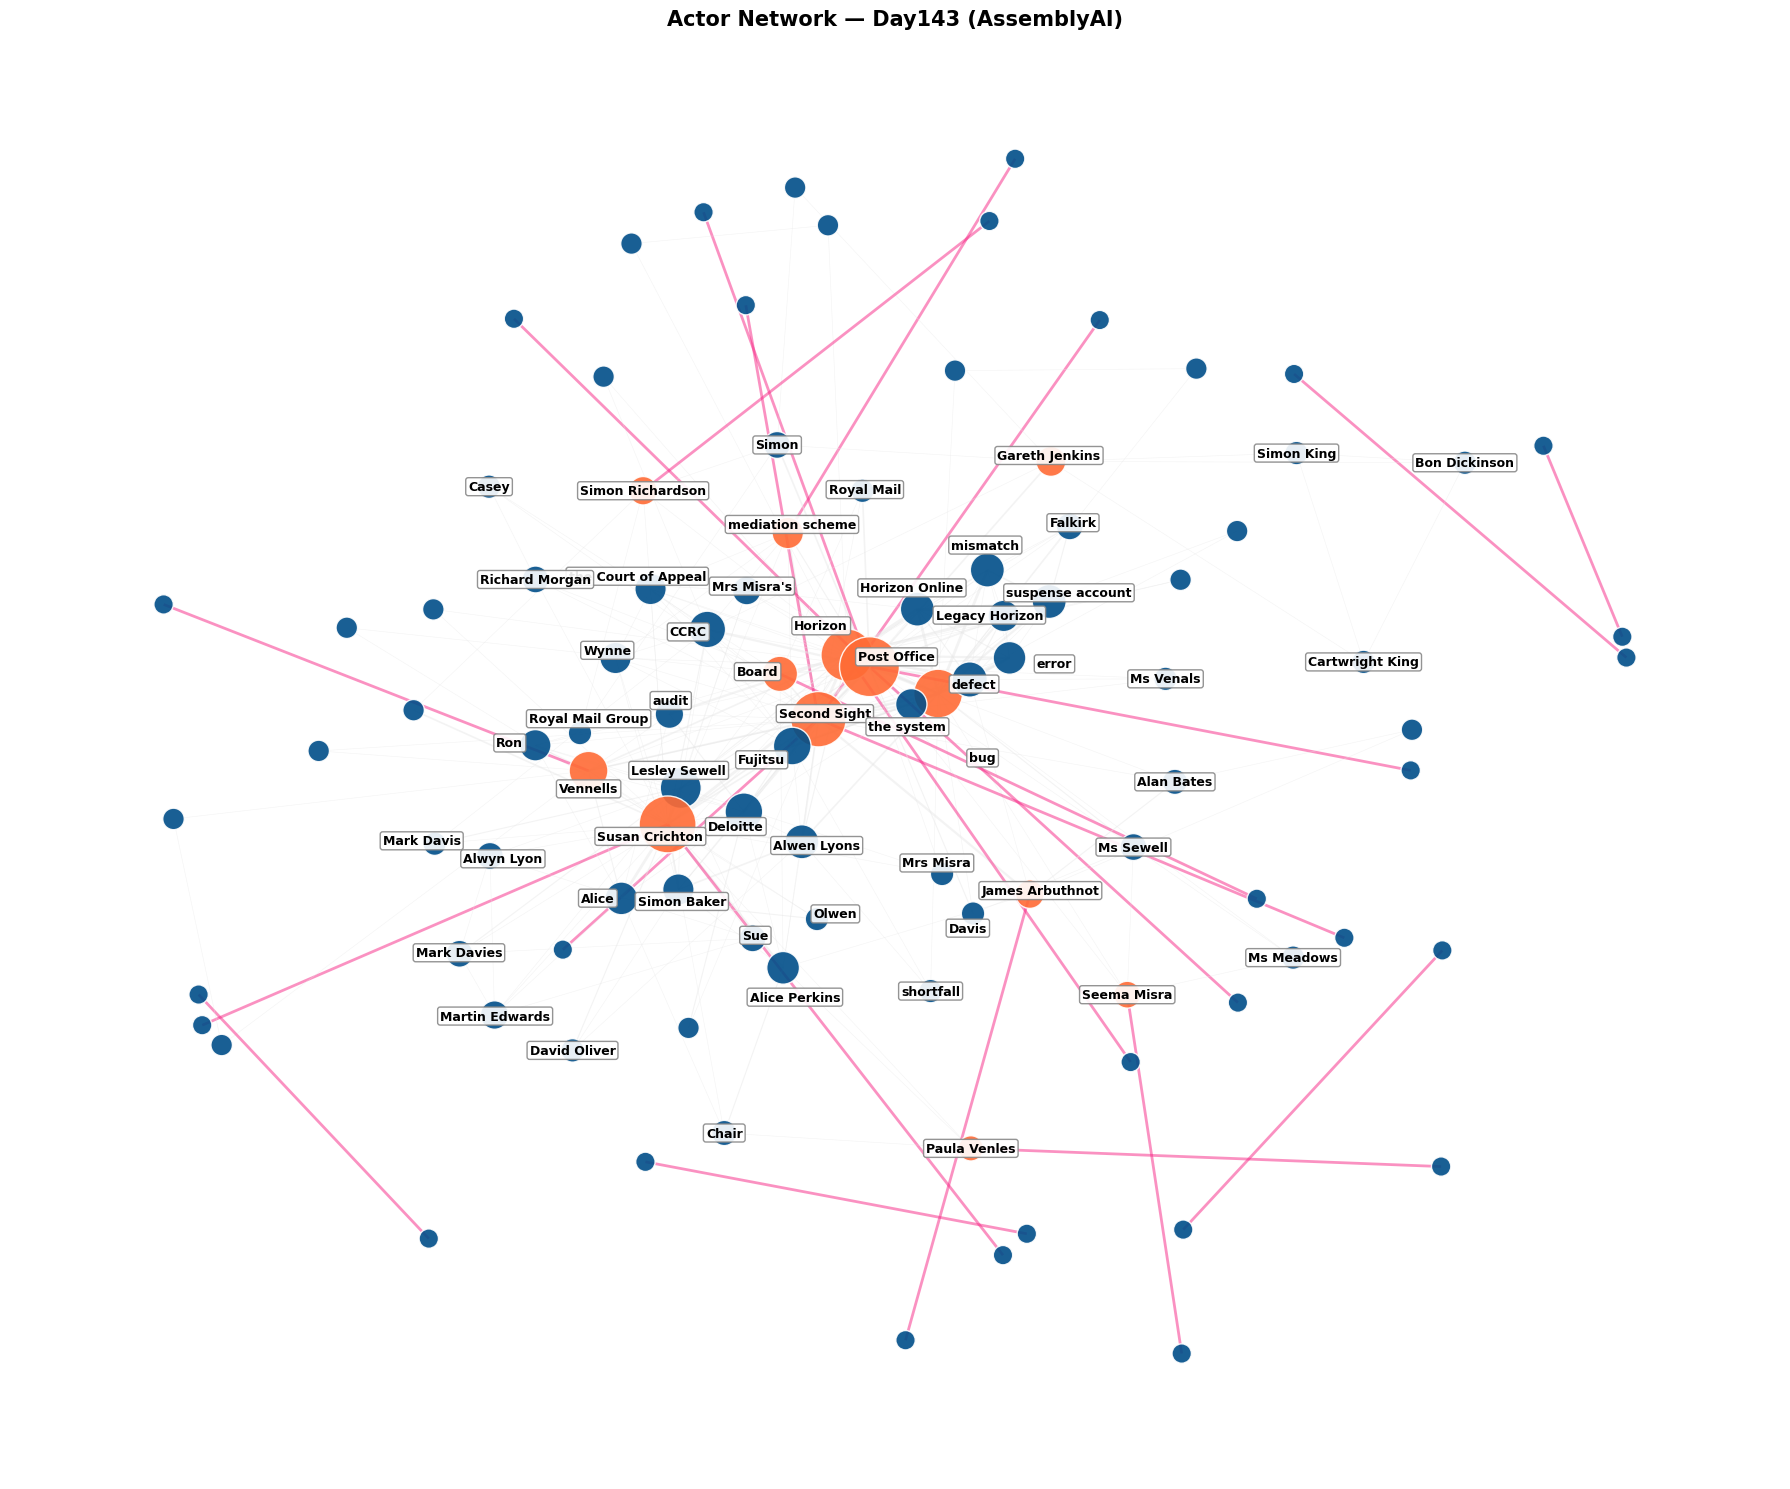

Saved: network_Day143.png

=== Day152 (AssemblyAI) — Fragility ===
Nodes: 120, Edges: 190, Density: 0.0266
Bridge edges: 39
   GE Capital -- Head of Fraud Management  (fragile — only path)
   GE Capital -- Citibank  (fragile — only path)
   Second Sight -- Second Sight Support Services Limited  (fragile — only path)
   Second Sight -- NDA  (fragile — only path)
   Post Office -- CRR  (fragile — only path)
   Post Office -- PinICL  (fragile — only path)
   Post Office -- Investigations Department  (fragile — only path)
   Post Office -- Mr Jenkins  (fragile — only path)
   Post Office -- Jones  (fragile — only path)
   Post Office -- Mrs Jeremiah  (fragile — only path)
Articulation points: 19
   Post Office (degree=49)
   Ian Henderson (degree=20)
   Susan Crichton (degree=15)
   Second Sight (degree=12)
   shortfall (degree=9)
   Ian (degree=9)
   bug (degree=7)
   MPs (degree=6)
   Vennells (degree=6)
   Alice Perkins (degree=5)
  'Ron Warmington' not found in Day152 network.


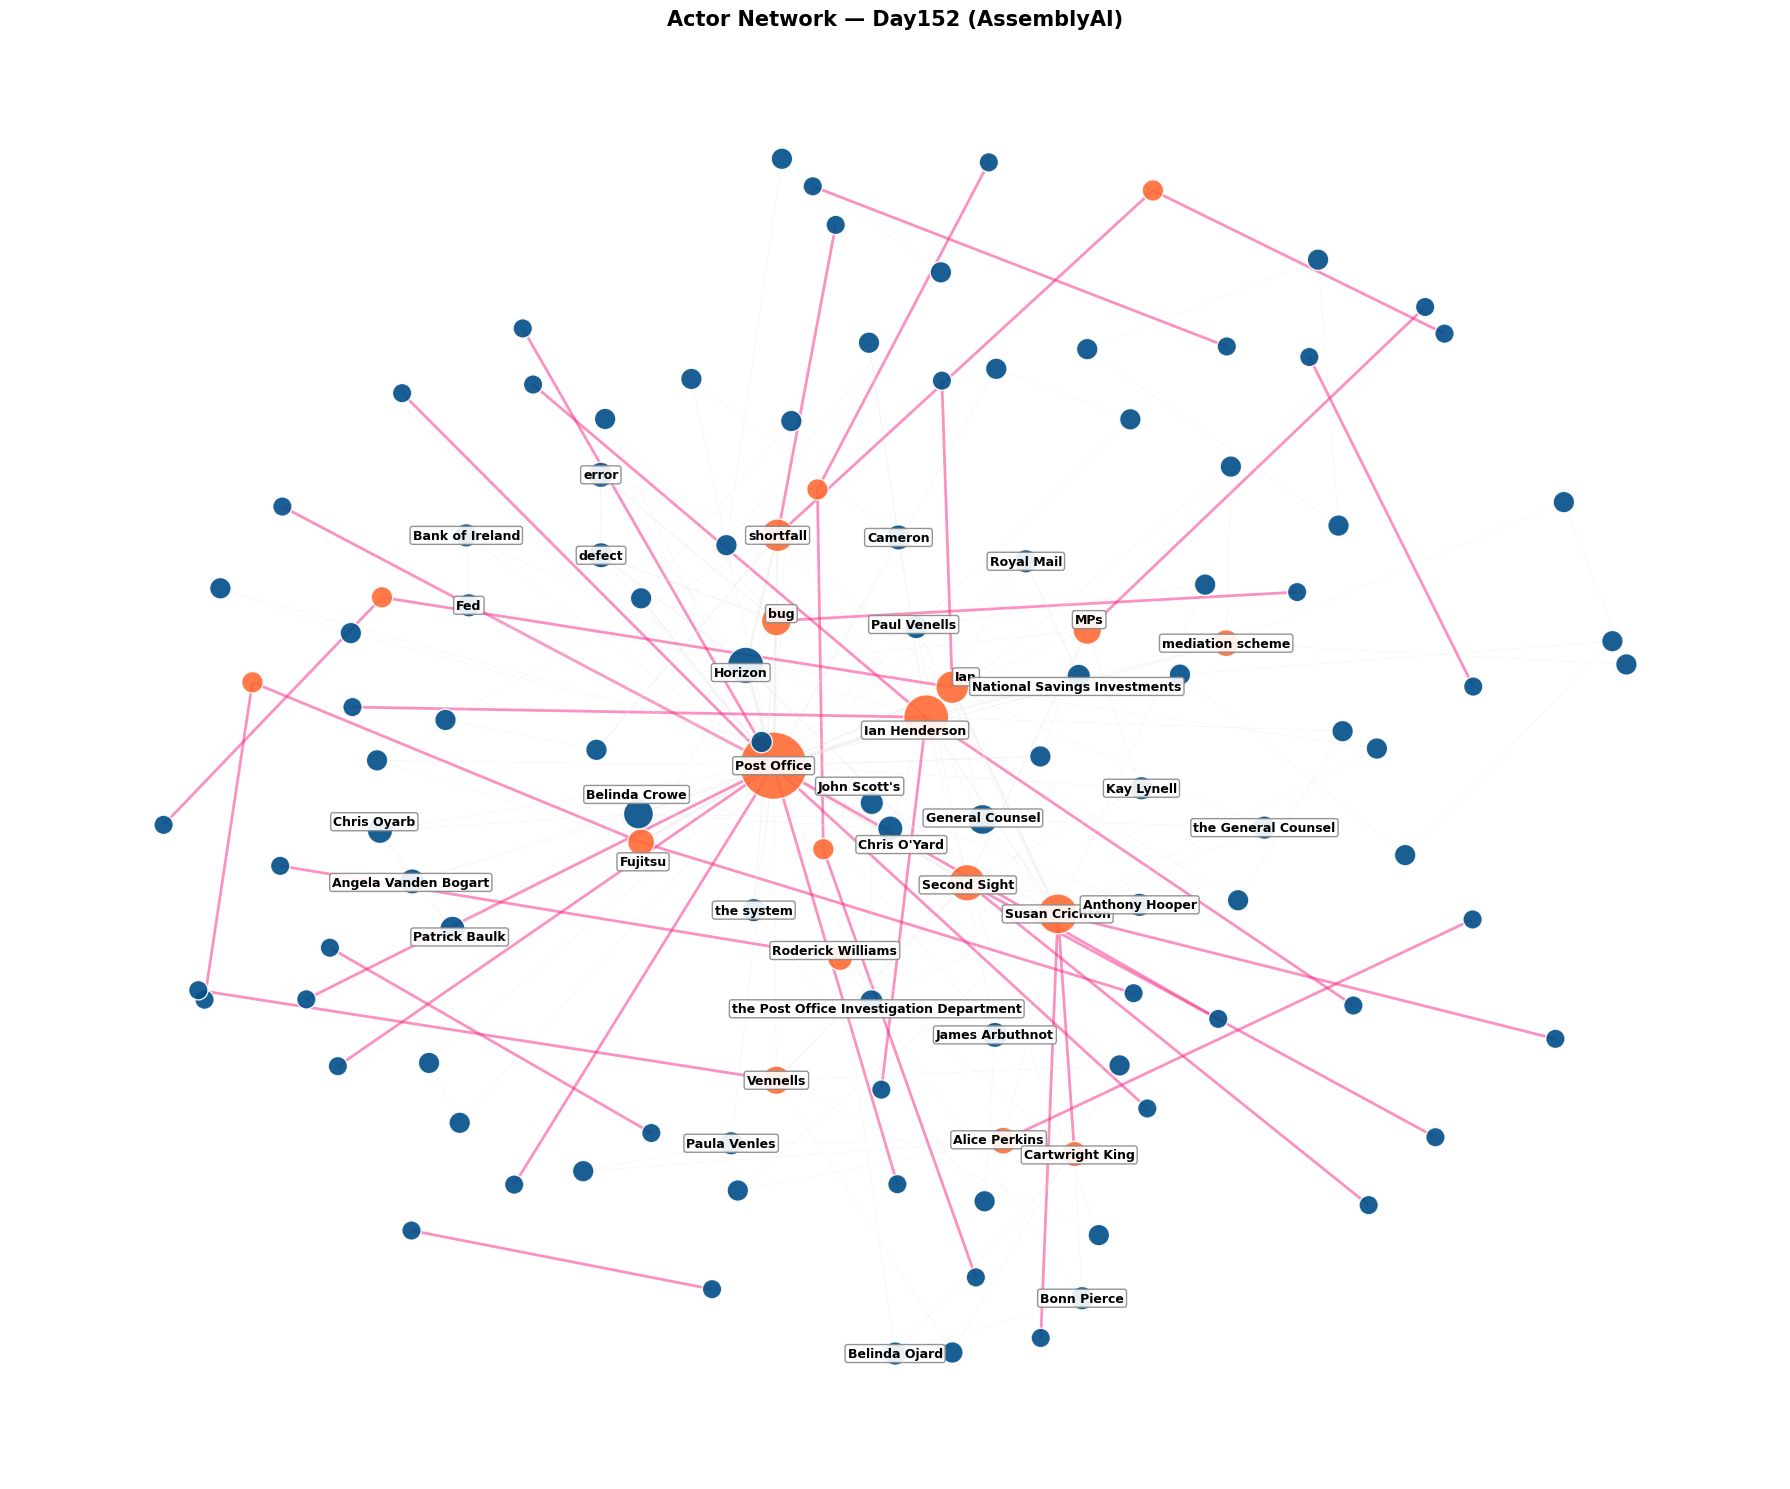

Saved: network_Day152.png

=== Day156 (AssemblyAI) — Fragility ===
Nodes: 122, Edges: 268, Density: 0.0363
Bridge edges: 29
   Cambridge University -- university,  (fragile — only path)
   ICL -- International Computers Limited  (fragile — only path)
   ICL -- Benefits Agency  (fragile — only path)
   Fujitsu -- ICL Fujitsu  (fragile — only path)
   Fujitsu -- Pearce  (fragile — only path)
   Project Impact -- the Bureau de Change  (fragile — only path)
   Project Impact -- Repos  (fragile — only path)
   Horizon -- Dave Baldwin  (fragile — only path)
   Horizon -- Saying  (fragile — only path)
   Post Office -- Oracle  (fragile — only path)
Articulation points: 16
   Post Office (degree=43)
   Fujitsu (degree=30)
   Horizon (degree=28)
   bug (degree=13)
   EPOSS (degree=13)
   Pinder (degree=12)
   Brian Pinder (degree=11)
   Project Impact (degree=8)
   Castleton (degree=7)
   Gareth (degree=7)
  42/121 entities have ONLY ONE path to reach Gareth Jenkins


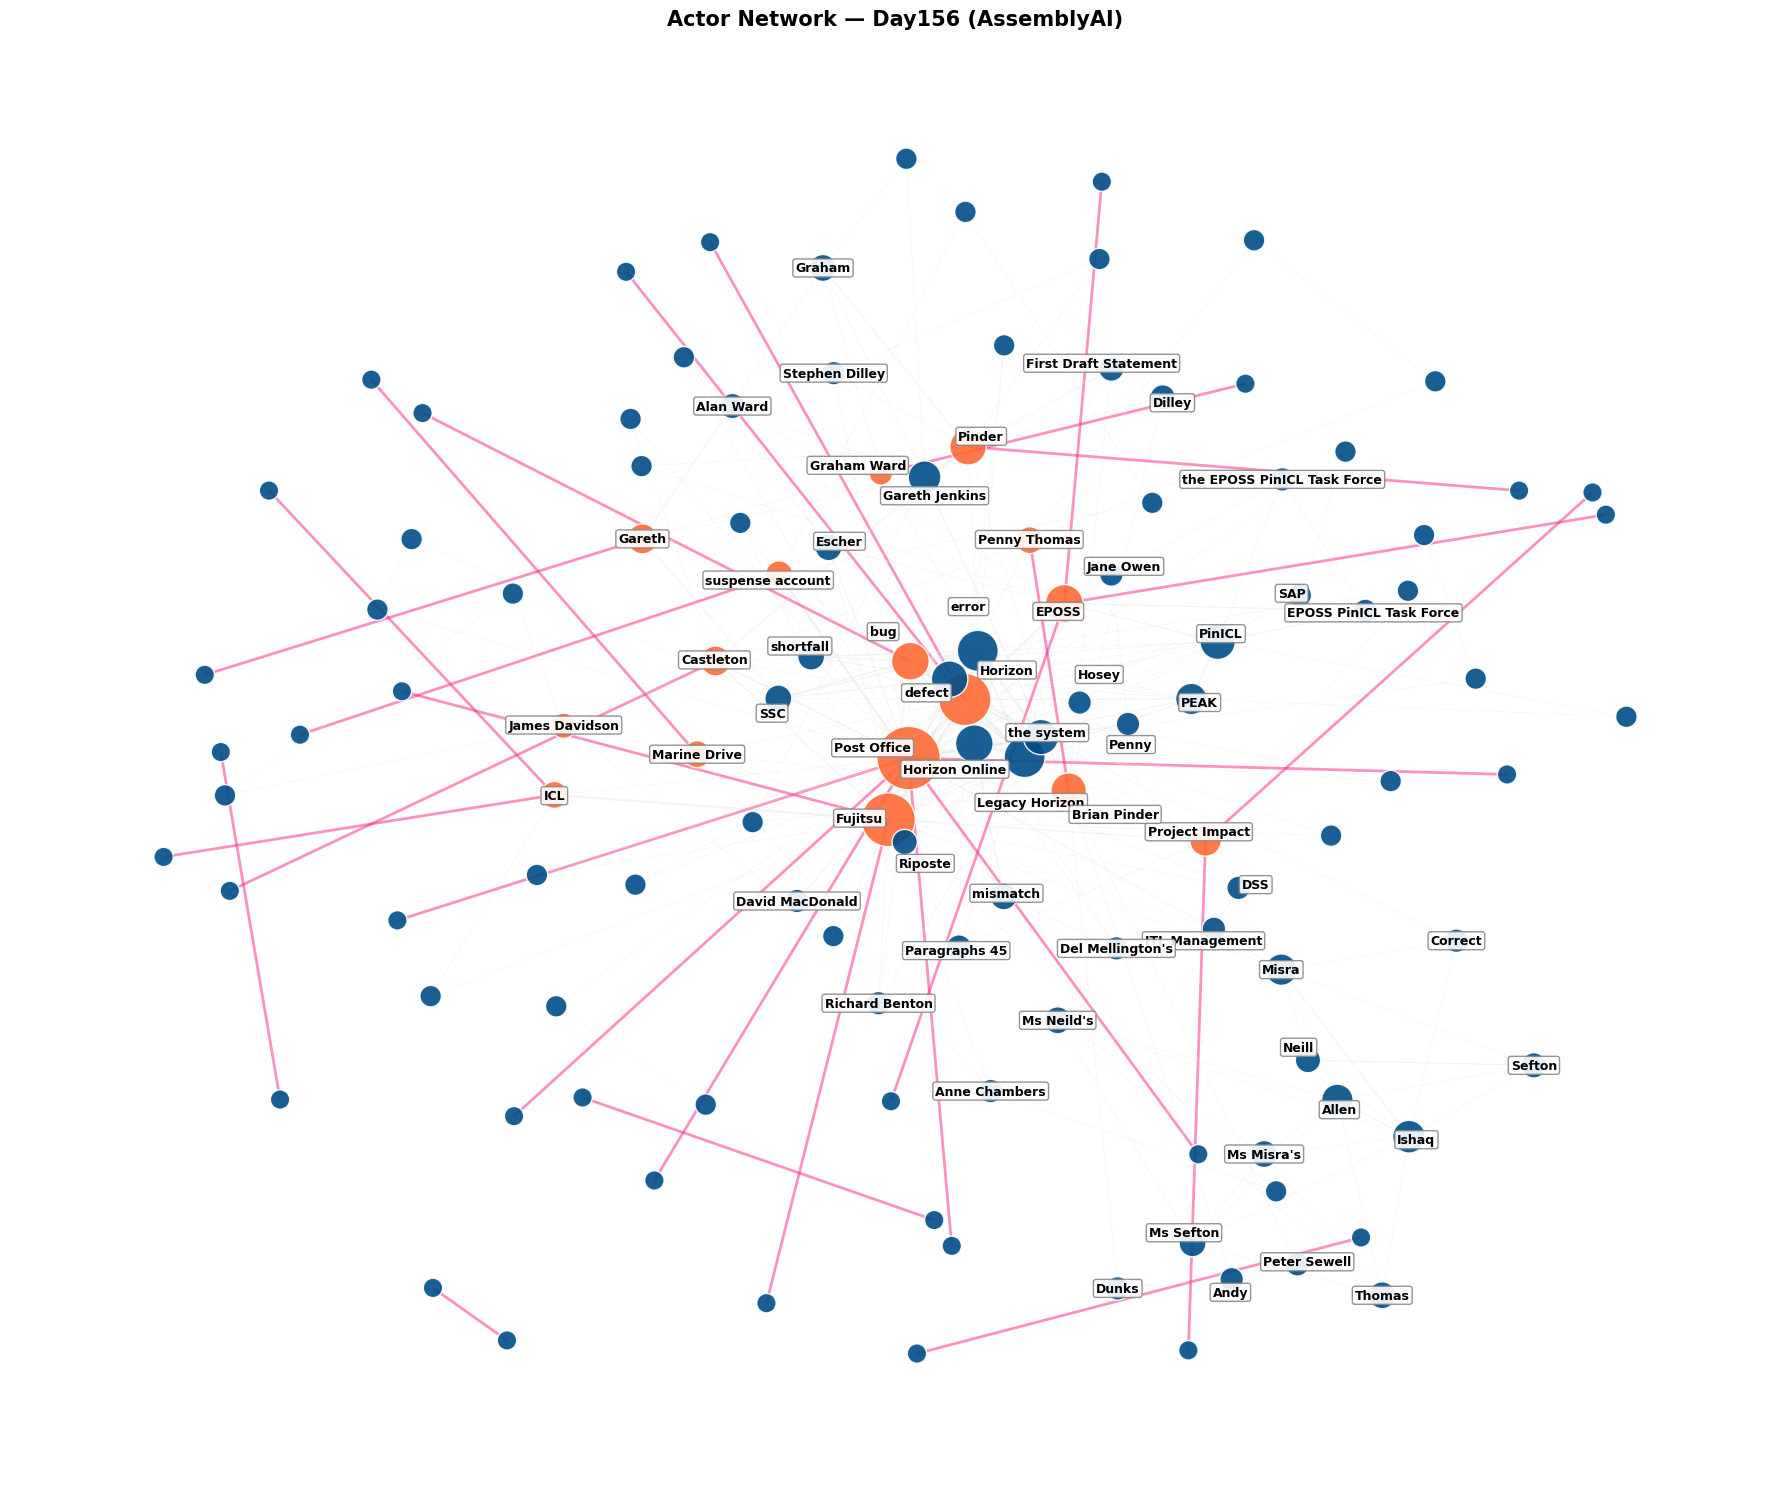

Saved: network_Day156.png

=== Day117 (AssemblyAI) — Fragility ===
Nodes: 88, Edges: 142, Density: 0.0371
Bridge edges: 28
   Post Office -- Microsoft Exchange  (fragile — only path)
   Post Office -- COVID  (fragile — only path)
   Post Office -- Patrick Baulk's  (fragile — only path)
   Post Office -- Phase 5/6  (fragile — only path)
   Post Office -- Craigadon Post Office  (fragile — only path)
   Post Office -- Justice Fraser  (fragile — only path)
   Post Office -- discrepancy  (fragile — only path)
   Post Office -- the Post Office Limited's  (fragile — only path)
   Post Office -- mediation scheme  (fragile — only path)
   Post Office -- the National Federation of Subpostmasters  (fragile — only path)
Articulation points: 7
   Post Office (degree=43)
   Horizon (degree=21)
   Alan Layton (degree=4)
   Microsoft Exchange (degree=2)
   Alan Bates (degree=2)
   Channel 4 (degree=2)
   Davey (degree=2)
  57/87 entities have ONLY ONE path to reach Alan Bates


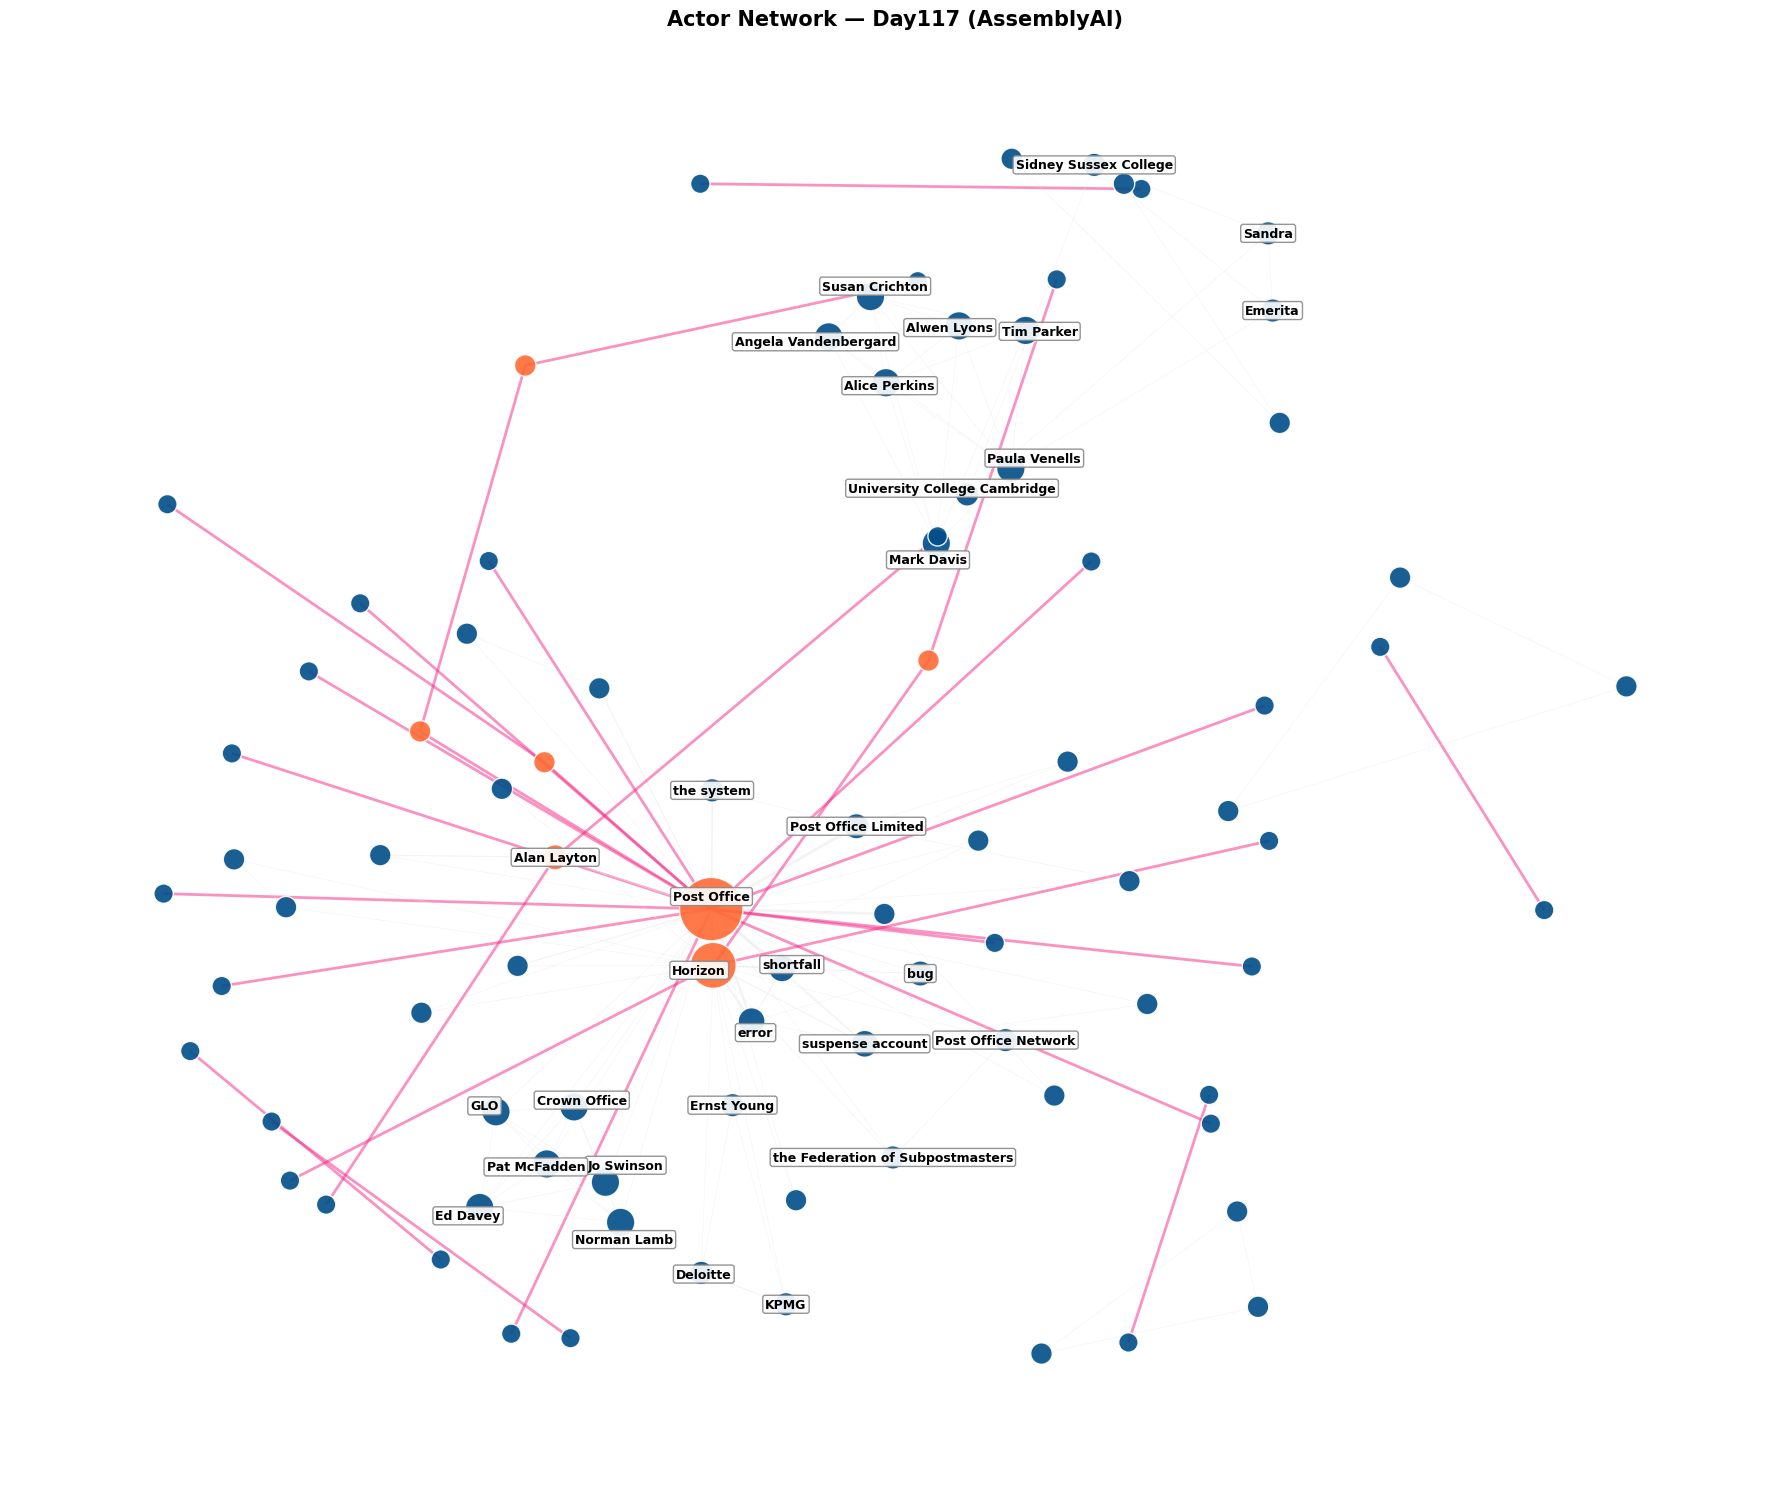

Saved: network_Day117.png

Saved: network_comparison_all_sessions.csv
        nodes  edges  density  bridges  articulation_points
Day143  101.0  280.0   0.0554     23.0                 13.0
Day152  120.0  190.0   0.0266     39.0                 19.0
Day156  122.0  268.0   0.0363     29.0                 16.0
Day117   88.0  142.0   0.0371     28.0                  7.0


In [16]:
NETWORK_SESSIONS = ["Day143", "Day152", "Day156", "Day117"]

def build_cooccurrence_network(df):
    G = nx.Graph()
    for sent_idx, group in df.groupby("sentence_index"):
        ents = list(set(group["entity_normalised"]))
        for a, b in combinations(sorted(ents), 2):
            if G.has_edge(a, b):
                G[a][b]["weight"] += 1
            else:
                G.add_edge(a, b, weight=1)
    return G

def compute_fragility_metrics(G, label, verbose=True):
    if verbose:
        print(f"\n=== {label} — Fragility ===")
    bridges = list(nx.bridges(G))
    articulation = list(nx.articulation_points(G))
    density = nx.density(G)
    constraint = nx.constraint(G, weight="weight")       # Burt (1992)
    effective_size = nx.effective_size(G, weight="weight")

    if verbose:
        print(f"Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}, Density: {density:.4f}")
        print(f"Bridge edges: {len(bridges)}")
        for u, v in bridges[:10]:
            print(f"   {u} -- {v}  (fragile — only path)")
        print(f"Articulation points: {len(articulation)}")
        for node in sorted(articulation, key=lambda n: G.degree(n), reverse=True)[:10]:
            print(f"   {node} (degree={G.degree(node)})")

    return {
        "nodes": G.number_of_nodes(), "edges": G.number_of_edges(),
        "density": round(density, 4), "bridges": len(bridges),
        "articulation_points": len(articulation),
        "constraint": constraint, "effective_size": effective_size,
    }

def check_redundancy_to_node(G, target, label):
    if target not in G.nodes():
        print(f"  '{target}' not found in {label} network.")
        return
    fragile = 0
    others = [n for n in G.nodes() if n != target]
    for node in others:
        if nx.has_path(G, node, target):
            try:
                if nx.node_connectivity(G, node, target) == 1:
                    fragile += 1
            except nx.NetworkXError:
                pass
    print(f"  {fragile}/{len(others)} entities have ONLY ONE path to reach {target}")

def resolve_label_overlaps(pos, nodes, min_dist=0.11, iterations=200):
    coords = {n: np.array(pos[n], dtype=float) for n in nodes}
    for _ in range(iterations):
        moved = False
        for i, a in enumerate(nodes):
            for b in nodes[i+1:]:
                delta = coords[a] - coords[b]
                dist = np.linalg.norm(delta)
                if dist < min_dist and dist > 1e-6:
                    push = (delta / dist) * (min_dist - dist) * 0.5
                    coords[a] += push; coords[b] -= push
                    moved = True
        if not moved:
            break
    return coords

def plot_network(G, title, filename, label_min_degree=3):
    bridges = set(nx.bridges(G))
    articulation = set(nx.articulation_points(G))
    fig, ax = plt.subplots(figsize=(18, 15))
    pos = nx.spring_layout(G, k=1.8, iterations=200, weight="weight", seed=42)

    edge_colors, edge_widths = [], []
    for u, v, d in G.edges(data=True):
        is_bridge = (u, v) in bridges or (v, u) in bridges
        edge_colors.append("#F72585" if is_bridge else "#E8E8E8")
        edge_widths.append(2.0 if is_bridge else min(d["weight"] * 0.4, 2))

    node_colors = ["#FF6B35" if n in articulation else "#004E89" for n in G.nodes()]
    node_sizes = [150 + G.degree(n) * 45 for n in G.nodes()]

    nx.draw_networkx_edges(G, pos, edge_color=edge_colors, width=edge_widths, alpha=0.5, ax=ax)
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes,
                            alpha=0.9, edgecolors="white", linewidths=1, ax=ax)

    labeled = [n for n in G.nodes() if G.degree(n) >= label_min_degree]
    label_pos = resolve_label_overlaps(pos, labeled)
    for node in labeled:
        lx, ly = label_pos[node]
        ax.text(lx, ly, node, fontsize=9, fontweight="bold", ha="center", va="center",
                bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="#888", alpha=0.9))

    ax.set_title(title, fontsize=15, fontweight="bold")
    ax.axis("off")
    plt.tight_layout()
    plt.savefig(filename, dpi=170, facecolor="white", bbox_inches="tight")
    plt.show()

network_metrics = {}
graphs = {}
for session in NETWORK_SESSIONS:
    df = entities_dfs[session]
    G = build_cooccurrence_network(df)
    graphs[session] = G
    metrics = compute_fragility_metrics(G, f"{session} (AssemblyAI)")
    anchor = SESSIONS[session]["anchor"]
    check_redundancy_to_node(G, anchor, session)
    network_metrics[session] = {k: v for k, v in metrics.items() if k not in ("constraint", "effective_size")}
    plot_network(G, f"Actor Network — {session} (AssemblyAI)", f"network_{session}.png")
    print(f"Saved: network_{session}.png")

network_comparison_df = pd.DataFrame(network_metrics).T
network_comparison_df.to_csv("network_comparison_all_sessions.csv")
print("\nSaved: network_comparison_all_sessions.csv")
print(network_comparison_df)


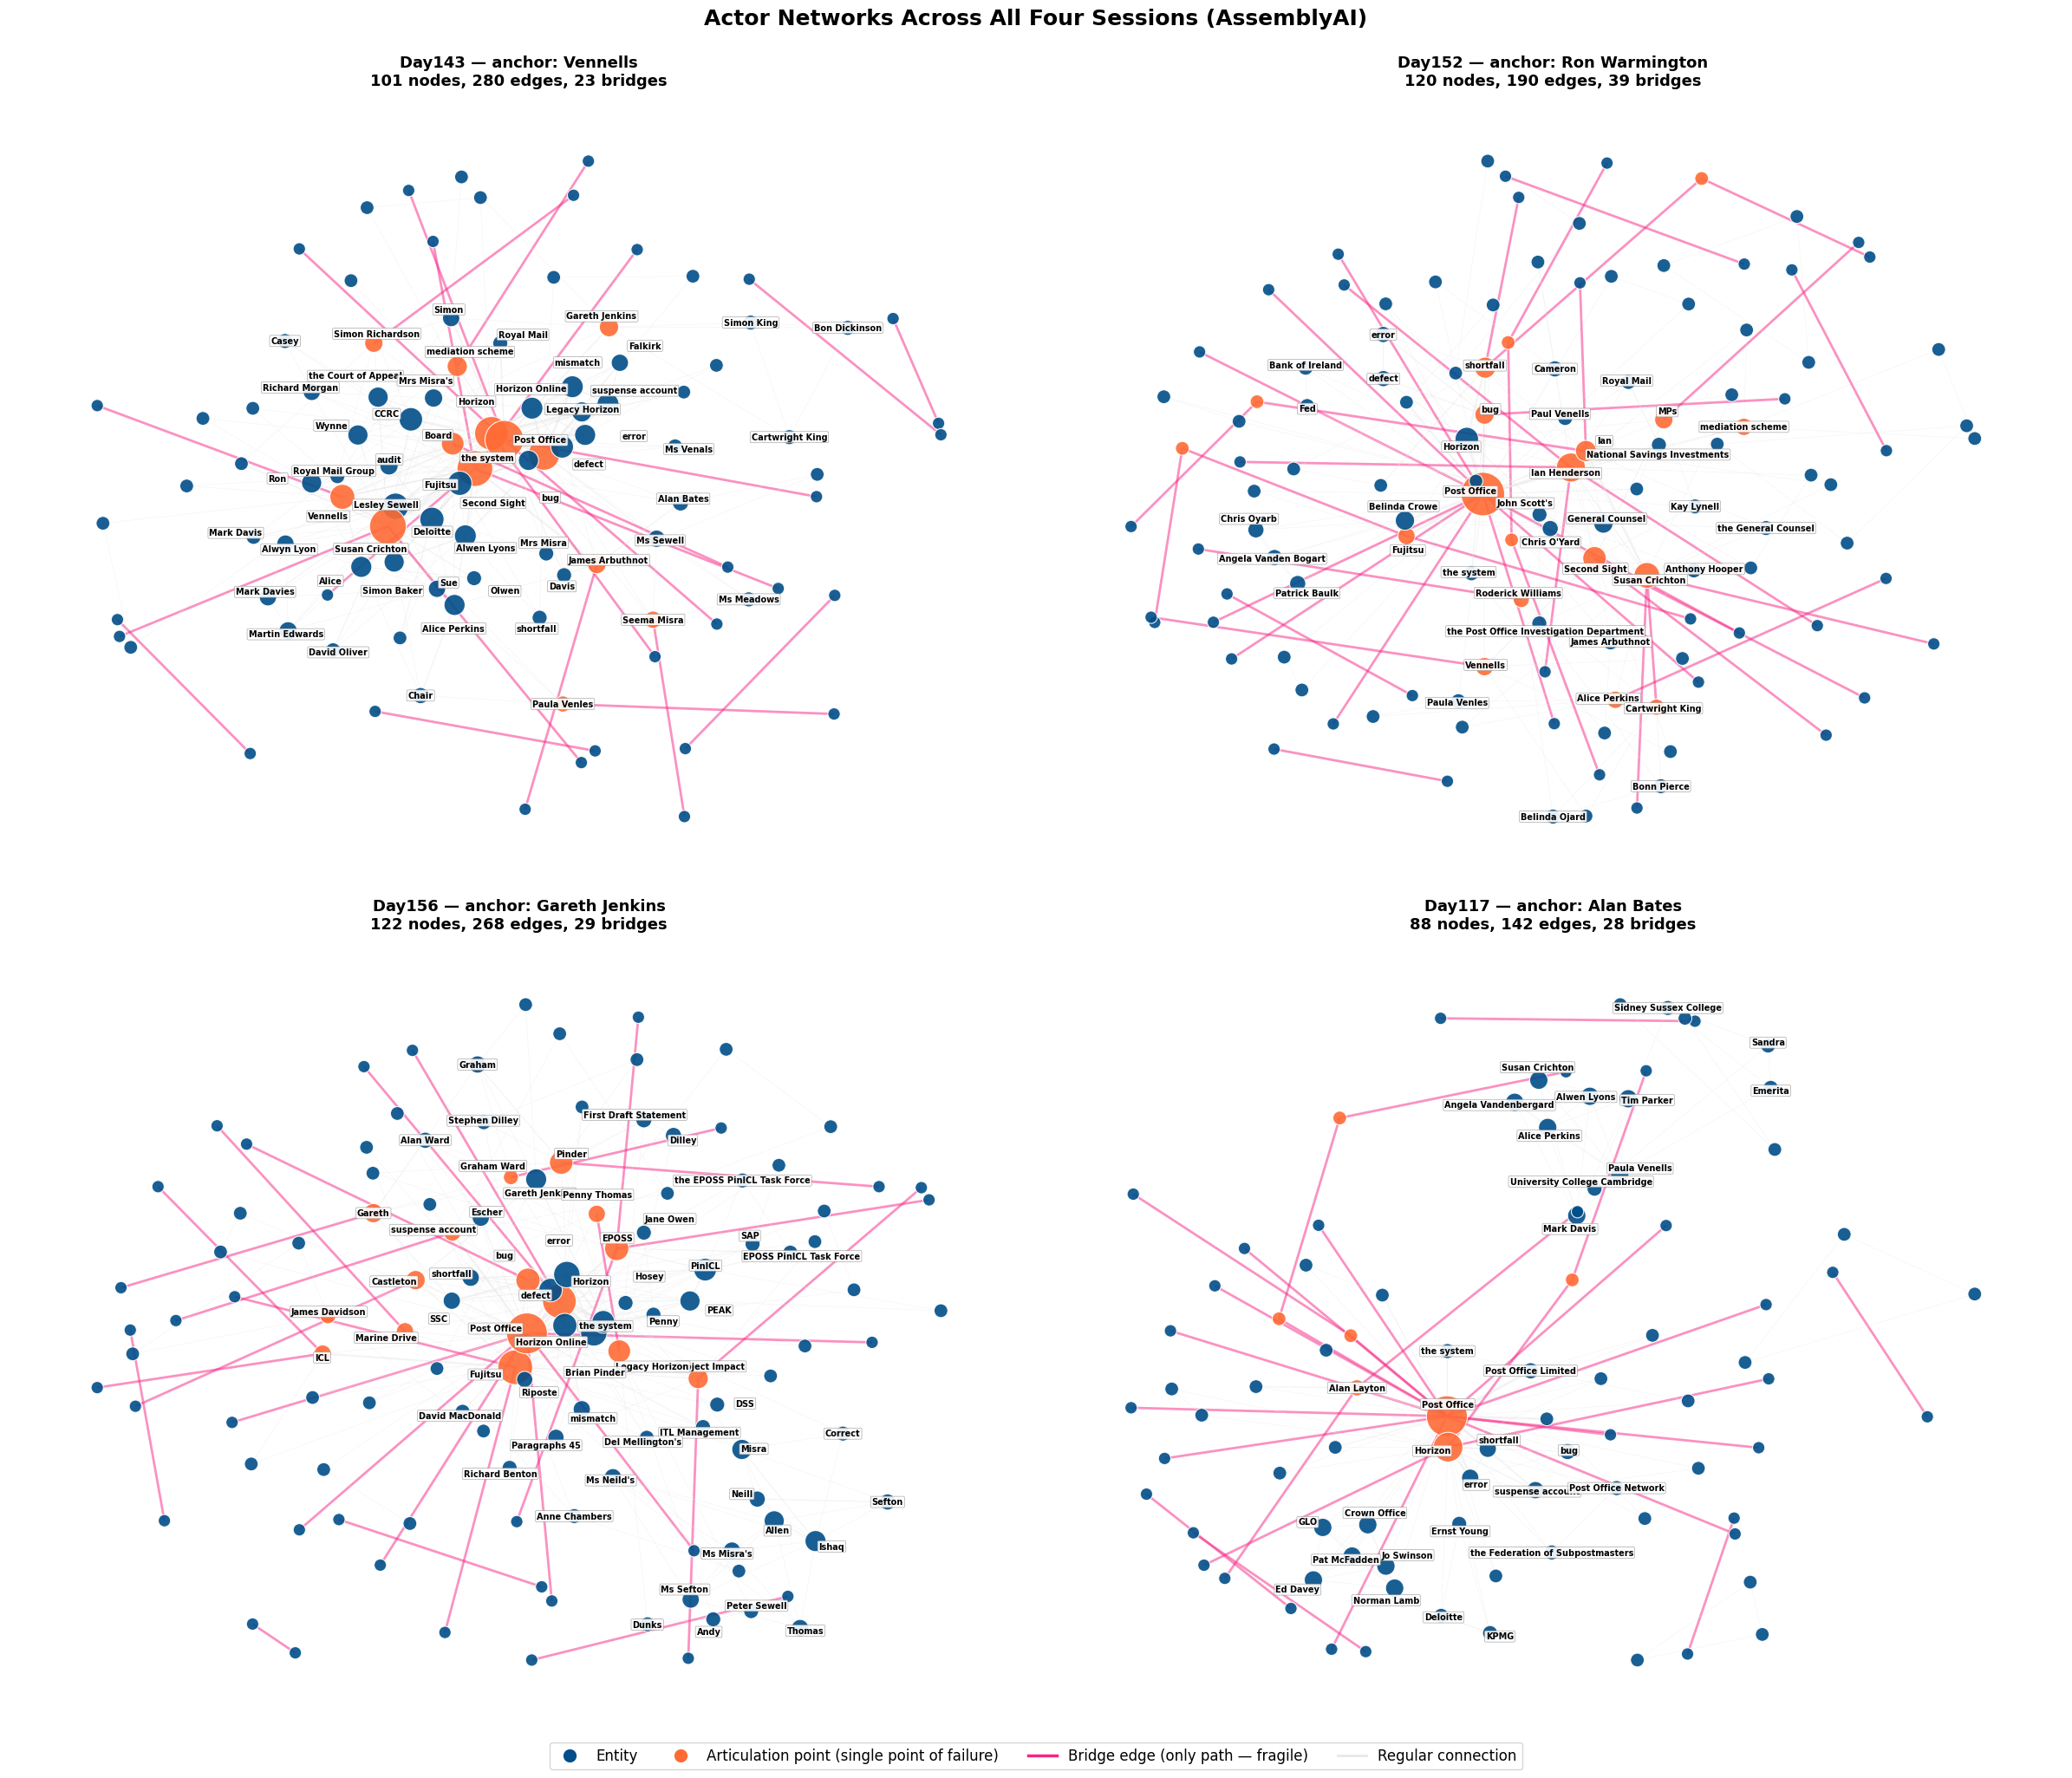

Saved: network_all_sessions_combined.png


In [17]:
# Combined network visualisation all 4 sessions in one figure
fig, axes = plt.subplots(2, 2, figsize=(24, 20))
axes = axes.flatten()

for idx, session in enumerate(NETWORK_SESSIONS):
    ax = axes[idx]
    G = graphs[session]
    bridges = set(nx.bridges(G))
    articulation = set(nx.articulation_points(G))
    pos = nx.spring_layout(G, k=1.8, iterations=200, weight="weight", seed=42)

    edge_colors, edge_widths = [], []
    for u, v, d in G.edges(data=True):
        is_bridge = (u, v) in bridges or (v, u) in bridges
        edge_colors.append("#F72585" if is_bridge else "#E8E8E8")
        edge_widths.append(2.0 if is_bridge else min(d["weight"] * 0.4, 2))

    node_colors = ["#FF6B35" if n in articulation else "#004E89" for n in G.nodes()]
    node_sizes = [80 + G.degree(n) * 25 for n in G.nodes()]

    nx.draw_networkx_edges(G, pos, edge_color=edge_colors, width=edge_widths, alpha=0.5, ax=ax)
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes,
                            alpha=0.9, edgecolors="white", linewidths=0.8, ax=ax)

    labeled = [n for n in G.nodes() if G.degree(n) >= 3]
    label_pos = resolve_label_overlaps(pos, labeled, min_dist=0.13)
    for node in labeled:
        lx, ly = label_pos[node]
        ax.text(lx, ly, node, fontsize=7, fontweight="bold", ha="center", va="center",
                bbox=dict(boxstyle="round,pad=0.15", facecolor="white", edgecolor="#888",
                          linewidth=0.4, alpha=0.9))

    anchor = SESSIONS[session]["anchor"]
    ax.set_title(f"{session} — anchor: {anchor}\n"
                 f"{G.number_of_nodes()} nodes, {G.number_of_edges()} edges, "
                 f"{network_metrics[session]['bridges']} bridges",
                 fontsize=13, fontweight="bold")
    ax.axis("off")

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#004E89', markersize=12, label='Entity'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#FF6B35', markersize=12, label='Articulation point (single point of failure)'),
    Line2D([0], [0], color='#F72585', linewidth=2.5, label='Bridge edge (only path — fragile)'),
    Line2D([0], [0], color='#E8E8E8', linewidth=2, label='Regular connection'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=4, fontsize=12, bbox_to_anchor=(0.5, -0.02))

fig.suptitle("Actor Networks Across All Four Sessions (AssemblyAI)", fontsize=18, fontweight="bold", y=1.00)
plt.tight_layout()
plt.savefig("network_all_sessions_combined.png", dpi=170, facecolor="white", bbox_inches="tight")
plt.show()
print("Saved: network_all_sessions_combined.png")


## 14.Network Construction and Fragility Metrics-Faster-Whisper (Secondary Pipeline)
 This is the network that Section 15 compares against the Assembly API network

In [18]:
fw_graphs = {}
fw_network_metrics = {}
for session in FW_SESSIONS:  # Day143, Day152, Day156
    df = fw_entities_dfs[session]
    G = build_cooccurrence_network(df)
    fw_graphs[session] = G
    metrics = compute_fragility_metrics(G, f"{session} (Faster-Whisper)")
    fw_network_metrics[session] = {k: v for k, v in metrics.items() if k not in ("constraint", "effective_size")}

fw_network_comparison_df = pd.DataFrame(fw_network_metrics).T
fw_network_comparison_df.to_csv("network_comparison_fw_sessions.csv")
print("\nSaved: network_comparison_fw_sessions.csv")
print(fw_network_comparison_df)



=== Day143 (Faster-Whisper) — Fragility ===
Nodes: 102, Edges: 269, Density: 0.0522
Bridge edges: 32
   Second Sight -- Richard
Morgan Casey  (fragile — only path)
   Second Sight -- Grant Thornton  (fragile — only path)
   Second Sight -- Kay Lynell  (fragile — only path)
   Second Sight -- James R. Buthnott  (fragile — only path)
   Lesley Sewell -- Mark Davies  (fragile — only path)
   Susan Crichton -- Wynn  (fragile — only path)
   Susan Crichton -- the Cartwright King's  (fragile — only path)
   Ron -- Susan Leslie  (fragile — only path)
   Horizon -- Horizon
Integrity  (fragile — only path)
   Horizon -- Horizon Computer System  (fragile — only path)
Articulation points: 14
   Post Office (degree=39)
   Susan Crichton (degree=33)
   Horizon (degree=31)
   Second Sight (degree=27)
   Vennells (degree=14)
   Alice Perkins (degree=12)
   Lesley Sewell (degree=12)
   Simon Baker (degree=7)
   Ron (degree=7)
   Gareth Jenkins (degree=4)

=== Day152 (Faster-Whisper) — Fragility ===
N

## 15. Cross-Pipeline Fragility Comparison -AssemblyAPI vs Faster-Whisper
This section directky answer RQ2 clause 
"Does this finding hold consistentlya cross independently constructed transcription pipelines?
For each session with both pipeline (Day 143, 152 and 156), this compares-
- Bridge overlap (Jaccard similarity of Bridge-edge sets)
- articulation point over lap (Jaccard similarity )
- Betweenness-centrality agreement (Spearman rank correlation, computed only over entities present in both network)

In [19]:
def jaccard(set_a, set_b):
    a, b = set(set_a), set(set_b)
    return len(a & b) / len(a | b) if (a | b) else float("nan")

pipeline_comparison_rows = []
for session in FW_SESSIONS:
    G_api, G_fw = graphs[session], fw_graphs[session]

    bridges_api = {frozenset(e) for e in nx.bridges(G_api)}
    bridges_fw  = {frozenset(e) for e in nx.bridges(G_fw)}
    artic_api = set(nx.articulation_points(G_api))
    artic_fw  = set(nx.articulation_points(G_fw))

    bc_api = nx.betweenness_centrality(G_api, weight="weight")
    bc_fw  = nx.betweenness_centrality(G_fw, weight="weight")
    shared_nodes = sorted(set(bc_api) & set(bc_fw))

    if len(shared_nodes) >= 3:
        rho, pval = spearmanr([bc_api[n] for n in shared_nodes],
                               [bc_fw[n] for n in shared_nodes])
    else:
        rho, pval = float("nan"), float("nan")

    pipeline_comparison_rows.append({
        "session": session,
        "bridge_jaccard": round(jaccard(bridges_api, bridges_fw), 4),
        "articulation_jaccard": round(jaccard(artic_api, artic_fw), 4),
        "betweenness_spearman_rho": round(rho, 4) if rho == rho else rho,
        "betweenness_spearman_p": round(pval, 4) if pval == pval else pval,
        "shared_nodes": len(shared_nodes),
        "api_nodes": G_api.number_of_nodes(),
        "fw_nodes": G_fw.number_of_nodes(),
    })

pipeline_comparison_df = pd.DataFrame(pipeline_comparison_rows)
pipeline_comparison_df.to_csv("api_vs_fw_fragility_comparison.csv", index=False)
print("Saved: api_vs_fw_fragility_comparison.csv")
display(pipeline_comparison_df)


Saved: api_vs_fw_fragility_comparison.csv


,session,bridge_jaccard,articulation_jaccard,betweenness_spearman_rho,betweenness_spearman_p,shared_nodes,api_nodes,fw_nodes
0,Day143,0.1000,0.3500,0.8671,0.0,63,101,102
1,Day152,0.2222,0.6818,0.7041,0.0,67,120,114
2,Day156,0.1429,0.5000,0.6614,0.0,80,122,118


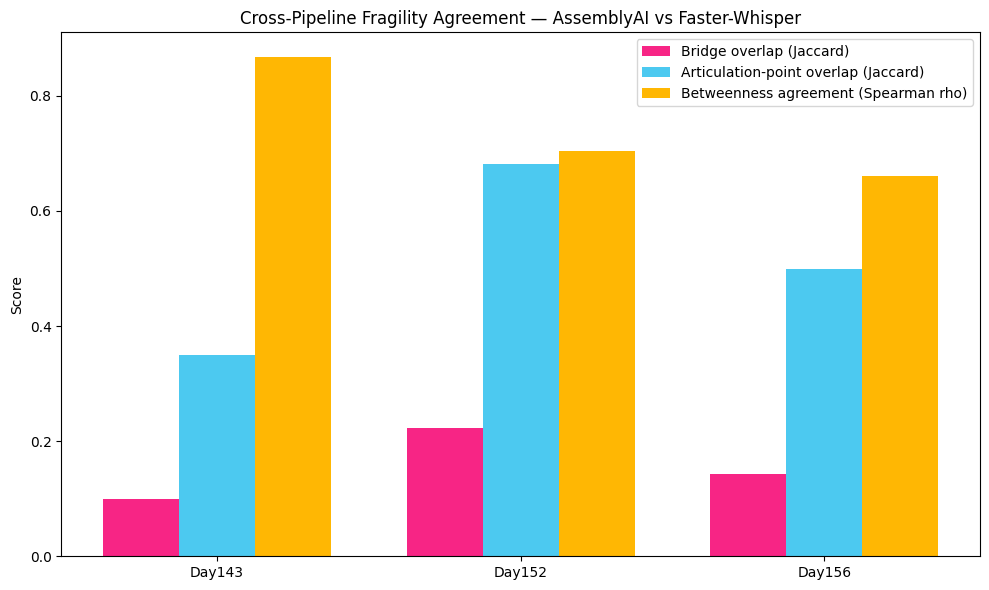

Saved: cross_pipeline_fragility_agreement.png


In [20]:
# Visualise cross-pipeline agreement #grouped barchart 
x = np.arange(len(pipeline_comparison_df))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width, pipeline_comparison_df["bridge_jaccard"], width, label="Bridge overlap (Jaccard)", color="#F72585")
ax.bar(x, pipeline_comparison_df["articulation_jaccard"], width, label="Articulation-point overlap (Jaccard)", color="#4CC9F0")
ax.bar(x + width, pipeline_comparison_df["betweenness_spearman_rho"], width, label="Betweenness agreement (Spearman rho)", color="#FFB703")

ax.set_ylabel("Score")
ax.set_title("Cross-Pipeline Fragility Agreement — AssemblyAI vs Faster-Whisper")
ax.set_xticks(x)
ax.set_xticklabels(pipeline_comparison_df["session"])
ax.axhline(0, color="black", linewidth=0.6)
ax.legend()
plt.tight_layout()
plt.savefig("cross_pipeline_fragility_agreement.png", dpi=200, facecolor="white")
plt.show()
print("Saved: cross_pipeline_fragility_agreement.png")


## 16. Combined Network (All Four Sessions Merges using AssemblyAPI

In [21]:
combined_rows = []
for session in NETWORK_SESSIONS:
    df = entities_dfs[session].copy()
    df["session"] = session
    combined_rows.append(df)

combined_entities_df = pd.concat(combined_rows, ignore_index=True)
combined_entities_df.to_csv("api_entities_ALL_SESSIONS.csv", index=False)
print(f"Saved: api_entities_ALL_SESSIONS.csv ({len(combined_entities_df)} total rows)")
print(combined_entities_df["session"].value_counts())

def build_combined_network(df):
    G = nx.Graph()
    for (session, sent_idx), group in df.groupby(["session", "sentence_index"]):
        ents = list(set(group["entity_normalised"]))
        for a, b in combinations(sorted(ents), 2):
            if G.has_edge(a, b):
                G[a][b]["weight"] += 1
                G[a][b]["sessions"].add(session)
            else:
                G.add_edge(a, b, weight=1, sessions={session})
    return G

G_combined = build_combined_network(combined_entities_df)
print(f"\nCombined network: {G_combined.number_of_nodes()} nodes, {G_combined.number_of_edges()} edges")

entity_category_map = (
    combined_entities_df.groupby("entity_normalised")["category"]
    .agg(lambda x: x.mode()[0]).to_dict()
)
entity_sessions = combined_entities_df.groupby("entity_normalised")["session"].agg(set)
cross_session_entities = {e for e, s in entity_sessions.items() if len(s) > 1}

print(f"\nEntities appearing in more than one session ({len(cross_session_entities)}):")
for e in sorted(cross_session_entities):
    print(f"  {e}: {sorted(entity_sessions[e])}")

bridges_combined = list(nx.bridges(G_combined))
articulation_combined = list(nx.articulation_points(G_combined))
print(f"\nCombined network — bridges: {len(bridges_combined)}, articulation points: {len(articulation_combined)}")

pd.DataFrame({
    "nodes": [G_combined.number_of_nodes()], "edges": [G_combined.number_of_edges()],
    "bridges": [len(bridges_combined)], "articulation_points": [len(articulation_combined)],
    "cross_session_entities": [len(cross_session_entities)],
}).to_csv("network_combined_metrics.csv", index=False)


Saved: api_entities_ALL_SESSIONS.csv (2661 total rows)
session
Day143    792
Day156    769
Day152    551
Day117    549
Name: count, dtype: int64

Combined network: 354 nodes, 787 edges

Entities appearing in more than one session (69):
  Alan: ['Day117', 'Day143', 'Day152']
  Alan Bates: ['Day117', 'Day143', 'Day152']
  Alice Perkins: ['Day117', 'Day143', 'Day152']
  Alwen Lyons: ['Day117', 'Day143', 'Day152']
  Angela Vanden Bogart: ['Day152', 'Day156']
  Anthony Hooper: ['Day143', 'Day152']
  BIS: ['Day117', 'Day143']
  Baker: ['Day117', 'Day143', 'Day152']
  Beer: ['Day117', 'Day143', 'Day152', 'Day156']
  CCRC: ['Day143', 'Day152']
  COVID: ['Day117', 'Day156']
  Cartwright King: ['Day143', 'Day152', 'Day156']
  Chair: ['Day143', 'Day152']
  Computer Weekly: ['Day117', 'Day152']
  Davis: ['Day117', 'Day143']
  Deloitte: ['Day117', 'Day143']
  EPOSS: ['Day117', 'Day156']
  Ernst Young: ['Day117', 'Day152']
  Fujitsu: ['Day143', 'Day152', 'Day156']
  GLO: ['Day117', 'Day152', 'Day156

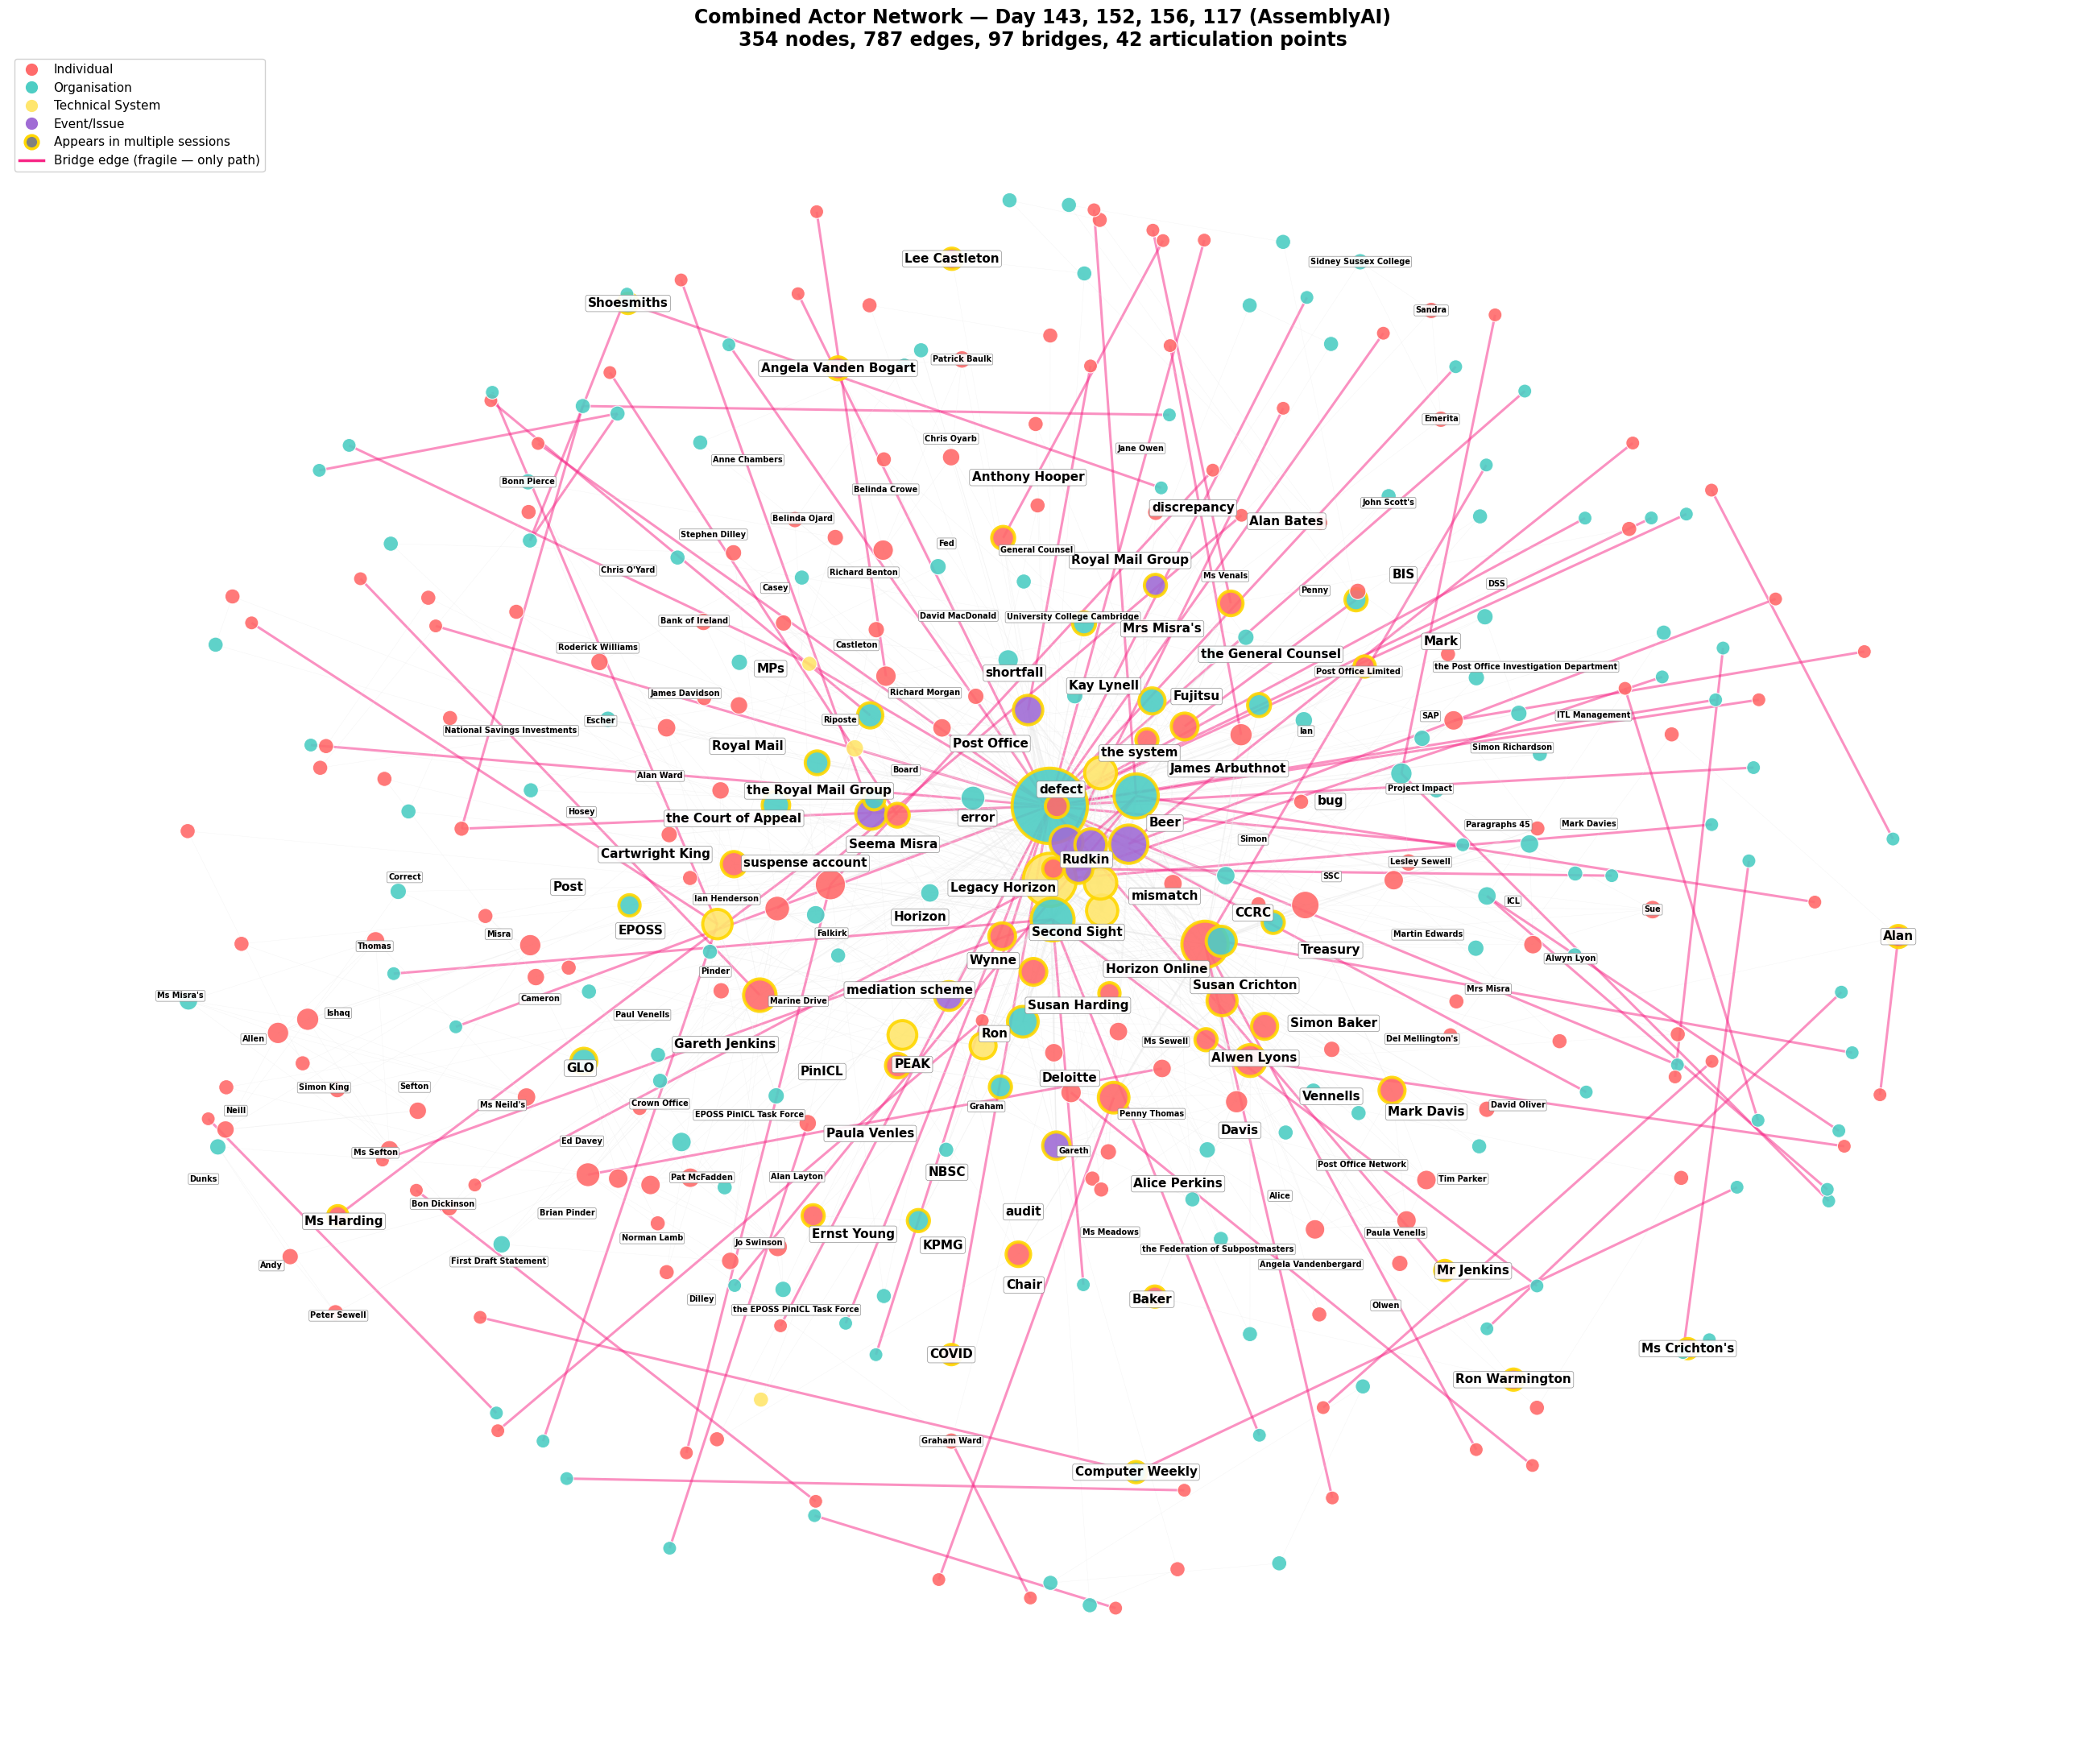

Saved: network_combined_all_sessions.png


In [22]:
def plot_combined_network(G, title, filename, label_min_degree=3):
    bridges = set(nx.bridges(G))
    articulation = set(nx.articulation_points(G))
    fig, ax = plt.subplots(figsize=(26, 22))
    pos = nx.spring_layout(G, k=1.6, iterations=250, weight="weight", seed=42)

    edge_colors, edge_widths = [], []
    for u, v, d in G.edges(data=True):
        is_bridge = (u, v) in bridges or (v, u) in bridges
        edge_colors.append("#F72585" if is_bridge else "#E8E8E8")
        edge_widths.append(2.2 if is_bridge else min(d["weight"] * 0.3, 2))

    node_colors = [CATEGORY_COLOURS.get(entity_category_map.get(n, ""), "#999999") for n in G.nodes()]
    node_sizes = [(300 if n in cross_session_entities else 120) + G.degree(n) * 30 for n in G.nodes()]
    node_edgecolors = ["#FFD700" if n in cross_session_entities else "white" for n in G.nodes()]
    node_linewidths = [2.8 if n in cross_session_entities else 0.8 for n in G.nodes()]

    nx.draw_networkx_edges(G, pos, edge_color=edge_colors, width=edge_widths, alpha=0.5, ax=ax)
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes,
                            alpha=0.9, edgecolors=node_edgecolors, linewidths=node_linewidths, ax=ax)

    labeled = [n for n in G.nodes() if G.degree(n) >= label_min_degree or n in cross_session_entities]
    label_pos = resolve_label_overlaps(pos, labeled, min_dist=0.1)
    for node in labeled:
        lx, ly = label_pos[node]
        fontsize = 11 if node in cross_session_entities else 7
        ax.text(lx, ly, node, fontsize=fontsize, fontweight="bold", ha="center", va="center",
                bbox=dict(boxstyle="round,pad=0.18", facecolor="white", edgecolor="#888",
                          linewidth=0.5, alpha=0.92))

    from matplotlib.lines import Line2D
    legend_elements = [Line2D([0],[0], marker='o', color='w', markerfacecolor=c, markersize=12, label=cat)
                        for cat, c in CATEGORY_COLOURS.items()]
    legend_elements += [
        Line2D([0],[0], marker='o', color='w', markerfacecolor='gray', markeredgecolor='#FFD700',
               markeredgewidth=2.5, markersize=12, label='Appears in multiple sessions'),
        Line2D([0],[0], color='#F72585', linewidth=2.5, label='Bridge edge (fragile — only path)'),
    ]
    ax.legend(handles=legend_elements, loc='upper left', fontsize=11, framealpha=0.9)

    ax.set_title(f"{title}\n{G.number_of_nodes()} nodes, {G.number_of_edges()} edges, "
                 f"{len(bridges)} bridges, {len(articulation)} articulation points",
                 fontsize=17, fontweight="bold")
    ax.axis("off")
    plt.tight_layout()
    plt.savefig(filename, dpi=170, facecolor="white", bbox_inches="tight")
    plt.show()

plot_combined_network(G_combined,
                       "Combined Actor Network — Day 143, 152, 156, 117 (AssemblyAI)",
                       "network_combined_all_sessions.png")
print("Saved: network_combined_all_sessions.png")


In [23]:
# Combined network — summary tables
from IPython.display import display

n_nodes = G_combined.number_of_nodes()
n_edges = G_combined.number_of_edges()
density = nx.density(G_combined)
avg_degree = sum(dict(G_combined.degree()).values()) / n_nodes
total_cooccurrences = sum(d["weight"] for _, _, d in G_combined.edges(data=True))
top_pairs = sorted(G_combined.edges(data=True), key=lambda x: -x[2]["weight"])[:10]

def style_table(df, caption, header_color="#1B4F72"):
    styled = (
        df.style
        .set_caption(caption)
        .set_table_styles([
            {"selector": "caption",
             "props": [("caption-side", "top"), ("font-size", "15px"),
                       ("font-weight", "bold"), ("color", header_color), ("padding", "8px 0")]},
            {"selector": "th",
             "props": [("background-color", header_color), ("color", "white"),
                       ("font-size", "12px"), ("padding", "8px"), ("text-align", "center")]},
            {"selector": "td",
             "props": [("padding", "7px 10px"), ("font-size", "12px"), ("text-align", "center")]},
            {"selector": "tr:nth-child(even)", "props": [("background-color", "#EBF5FB")]},
            {"selector": "tr:nth-child(odd)", "props": [("background-color", "#FFFFFF")]},
            {"selector": "table",
             "props": [("border-collapse", "collapse"), ("margin-bottom", "24px"),
                       ("width", "100%"), ("border", "1px solid #D5D8DC")]},
        ])
        .hide(axis="index")
    )
    return styled

summary_df = pd.DataFrame([{
    "Nodes": n_nodes, "Edges": n_edges, "Density": round(density, 4),
    "Avg degree": round(avg_degree, 2), "Total co-occurrences": total_cooccurrences,
    "Bridges": len(bridges_combined), "Articulation points": len(articulation_combined),
    "Cross-session entities": len(cross_session_entities),
}])
display(style_table(summary_df, "Combined Network — Overall Metrics", "#1B4F72"))

top_pairs_df = pd.DataFrame([
    {"Rank": i+1, "Entity A": u, "Entity B": v, "Co-occurrences": d["weight"]}
    for i, (u, v, d) in enumerate(top_pairs)
])
display(style_table(top_pairs_df, "Top 10 Strongest Co-occurrence Pairs", "#117A65"))

articulation_df = pd.DataFrame({
    "Entity": articulation_combined,
    "Degree": [G_combined.degree(n) for n in articulation_combined]
}).sort_values("Degree", ascending=False).reset_index(drop=True)
articulation_df.insert(0, "Rank", range(1, len(articulation_df)+1))
display(style_table(articulation_df, "Articulation Points (sorted by degree)", "#6C3483"))

bridges_df = pd.DataFrame(bridges_combined, columns=["Entity A", "Entity B"])
bridges_df.insert(0, "Rank", range(1, len(bridges_df)+1))
display(style_table(bridges_df, "Bridge Edges (fragile — only path)", "#922B21"))

summary_df.to_csv("network_combined_full_metrics.csv", index=False)
top_pairs_df.to_csv("network_combined_top_pairs.csv", index=False)
articulation_df.to_csv("network_combined_articulation_points.csv", index=False)
bridges_df.to_csv("network_combined_bridges.csv", index=False)
print("Saved: network_combined_full_metrics.csv, network_combined_top_pairs.csv, "
      "network_combined_articulation_points.csv, network_combined_bridges.csv")


Nodes,Edges,Density,Avg degree,Total co-occurrences,Bridges,Articulation points,Cross-session entities
354,787,0.012600,4.450000,1477,97,42,69


Rank,Entity A,Entity B,Co-occurrences
1,Post Office,Horizon,51
2,Post Office,Second Sight,48
3,Horizon,bug,32
4,error,bug,28
5,bug,defect,27
6,error,defect,26
7,Horizon,error,25
8,Horizon,Horizon Online,25
9,Horizon,defect,23
10,Post Office,Fujitsu,22


Rank,Entity,Degree
1,Post Office,141
2,Horizon,65
3,Susan Crichton,47
4,Fujitsu,42
5,Second Sight,39
6,bug,29
7,Ian Henderson,20
8,Gareth Jenkins,18
9,Vennells,17
10,suspense account,16


Rank,Entity A,Entity B
1,Post Office,Microsoft Exchange
2,Post Office,COVID
3,Post Office,Patrick Baulk's
4,Post Office,Phase 5/6
5,Post Office,Craigadon Post Office
6,Post Office,Justice Fraser
7,Post Office,the Post Office Limited's
8,Post Office,the National Federation of Subpostmasters
9,Post Office,Davey
10,Post Office,Alliance


Saved: network_combined_full_metrics.csv, network_combined_top_pairs.csv, network_combined_articulation_points.csv, network_combined_bridges.csv


In [24]:
sms_rows = combined_entities_df[combined_entities_df["entity_normalised"] == "SMS"]
print(sms_rows[["session", "entity_raw", "category", "sentence_text"]].to_string())

     session entity_raw      category                                                                                                                                                                                                                                                                           sentence_text
2143  Day117        SMS  Organisation  Quote, Mr. Jackson then took the inquiry legal team through the work completed by the Post Office regarding other potential document sources, including Mimecast, SMS and instant messaging, and e-media sources, brackets, corporate devices, servers, backup tapes, and file stores.


In [25]:
# Section 16a. Burt's Constraint and Effective Size — Combined Network
degrees_combined = dict(G_combined.degree())
constraint_combined = nx.constraint(G_combined, weight="weight")
effsize_combined = nx.effective_size(G_combined, weight="weight")

top15 = sorted(degrees_combined.items(), key=lambda kv: -kv[1])[:15]

constraint_rows = [{
    "Entity": e,
    "Degree": deg,
    "Constraint": round(constraint_combined[e], 3),
    "Effective Size": round(effsize_combined[e], 2),
} for e, deg in top15]

constraint_df = pd.DataFrame(constraint_rows)
constraint_df.to_csv("burt_constraint_effective_size_top15.csv", index=False)
display(style_table(constraint_df, "Burt's Constraint and Effective Size — Top 15 Actors, Combined Network", "#1B4F72"))

Entity,Degree,Constraint,Effective Size
Post Office,141,0.099000,138.720000
Horizon,65,0.205000,62.130000
Susan Crichton,47,0.087000,44.810000
Fujitsu,42,0.212000,39.060000
Second Sight,39,0.250000,36.280000
bug,29,0.276000,26.050000
Ian Henderson,20,0.172000,18.130000
error,19,0.391000,15.590000
Gareth Jenkins,18,0.135000,16.440000
Legacy Horizon,18,0.376000,14.690000


## 17 Gephi Export
Networks built in section 13 as graphs exported as edge node CSV files and visualised in Gephu using the ForceAtLas 2 layout for the day 143 and combined session figures used in the research.

In [26]:
os.makedirs("gephi_export", exist_ok=True)

for session, G in graphs.items():
    edges = [{"Source": u, "Target": v, "Weight": d.get("weight", 1)}
             for u, v, d in G.edges(data=True)]
    pd.DataFrame(edges).to_csv(f"gephi_export/{session}_edges.csv", index=False)

    nodes = []
    for n in G.nodes():
        cat = "Unknown"
        if session in entities_dfs:
            match = entities_dfs[session][entities_dfs[session]["entity_normalised"] == n]
            if len(match) > 0:
                cat = match["category"].iloc[0]
        nodes.append({"Id": n, "Label": n, "Category": cat, "Degree": G.degree(n)})
    pd.DataFrame(nodes).to_csv(f"gephi_export/{session}_nodes.csv", index=False)

    print(f"Saved: gephi_export/{session}_edges.csv and {session}_nodes.csv")

# Combined network all sessions for Gephi
edges = [{"Source": u, "Target": v, "Weight": d.get("weight", 1)}
         for u, v, d in G_combined.edges(data=True)]
pd.DataFrame(edges).to_csv("gephi_export/ALL_SESSIONS_edges.csv", index=False)

nodes = [{"Id": n, "Label": n, "Degree": G_combined.degree(n)} for n in G_combined.nodes()]
pd.DataFrame(nodes).to_csv("gephi_export/ALL_SESSIONS_nodes.csv", index=False)

print("Saved: gephi_export/ALL_SESSIONS_edges.csv and ALL_SESSIONS_nodes.csv")
print(f"Combined network: {G_combined.number_of_nodes()} nodes, {G_combined.number_of_edges()} edges")


Saved: gephi_export/Day143_edges.csv and Day143_nodes.csv
Saved: gephi_export/Day152_edges.csv and Day152_nodes.csv
Saved: gephi_export/Day156_edges.csv and Day156_nodes.csv
Saved: gephi_export/Day117_edges.csv and Day117_nodes.csv
Saved: gephi_export/ALL_SESSIONS_edges.csv and ALL_SESSIONS_nodes.csv
Combined network: 354 nodes, 787 edges


## 18. GitHub Export Package

In [27]:
import shutil

github_folder = "github_export"
os.makedirs(github_folder, exist_ok=True)

per_session_csvs = [f"api_entities_{s}.csv" for s in NETWORK_SESSIONS]
fw_csvs = [f"fw_entities_{s}.csv" for s in FW_SESSIONS]
combined_csv = "api_entities_ALL_SESSIONS.csv"

network_csvs = [
    "network_comparison_all_sessions.csv",
    "network_comparison_fw_sessions.csv",
    "api_vs_fw_fragility_comparison.csv",
    "network_combined_full_metrics.csv",
    "network_combined_bridges.csv",
    "network_combined_articulation_points.csv",
]

all_csvs = per_session_csvs + fw_csvs + [combined_csv] + network_csvs

missing = []
for fname in all_csvs:
    if os.path.exists(fname):
        shutil.copy(fname, os.path.join(github_folder, fname))
    else:
        missing.append(fname)

if missing:
    print("WARNING — these expected files were not found (run the relevant earlier cell first):")
    for m in missing:
        print(f"  {m}")

readme_text = """# Post Office Horizon IT Inquiry — Data Export

Generated from the dissertation analysis notebook (Day 143, 152, 156, 117).

## Per-session entity data
- api_entities_Day143.csv / Day152.csv / Day156.csv / Day117.csv
  One row per entity mention (AssemblyAI, primary pipeline): sentence_index,
  entity_raw, entity_normalised, category, sentence_text.
- fw_entities_Day143.csv / Day152.csv / Day156.csv
  Same structure, Faster-Whisper (secondary pipeline), used only for the
  cross-pipeline fragility comparison.

## Combined entity data
- api_entities_ALL_SESSIONS.csv — all 4 AssemblyAI sessions stacked, with a `session` column.

## Network metrics
- network_comparison_all_sessions.csv — per-session AssemblyAI network stats.
- network_comparison_fw_sessions.csv — per-session Faster-Whisper network stats.
- api_vs_fw_fragility_comparison.csv — Jaccard/Spearman cross-pipeline comparison (RQ2).
- network_combined_full_metrics.csv — combined AssemblyAI network stats.
- network_combined_bridges.csv / network_combined_articulation_points.csv

## Categories
Individual, Organisation, Technical System, Event/Issue — see dissertation Chapter 3.

## Note
The Comparative Study (Rishi Sunak, Infected Blood Inquiry) is excluded from all
files here — only WER was computed for that session, not NER or network analysis.
"""
with open(os.path.join(github_folder, "README.md"), "w", encoding="utf-8") as f:
    f.write(readme_text)

print(f"\nGitHub export ready in ./{github_folder}/")
print(f"Contains {len([f for f in all_csvs if f not in missing])} CSV files + README.md")
for f in sorted(os.listdir(github_folder)):
    print(f"  {f}")



GitHub export ready in ./github_export/
Contains 14 CSV files + README.md
  .ipynb_checkpoints
  Day 143 Gephi Vis.png
  OFFICIAL_Sunak_InfectedBlood.pdf
  README.md
  actor_event_actor_chains.csv
  api_entities_ALL_SESSIONS.csv
  api_entities_Day117.csv
  api_entities_Day143.csv
  api_entities_Day152.csv
  api_entities_Day156.csv
  api_vs_fw_fragility_comparison.csv
  betweenness_combined_top15.csv
  fw_entities_Day143.csv
  fw_entities_Day152.csv
  fw_entities_Day156.csv
  network_combined_articulation_points.csv
  network_combined_bridges.csv
  network_combined_cooccurrence_matrix.csv
  network_combined_full_metrics.csv
  network_comparison_all_sessions.csv
  network_comparison_fw_sessions.csv
  relations_Day117_for_manual_review.csv
  relations_Day143_for_manual_review.csv
  relations_Day152_for_manual_review.csv
  relations_Day156_for_manual_review.csv
  wer_comparison_table.csv


## 19. Relation extraction pilot run on Assembly API (priamry pipeline) cleaned transcripts for Day 143, 152, 156

In [28]:
ent_df = pd.read_csv("api_entities_ALL_SESSIONS.csv")

valid_entities = (
    ent_df["entity_normalised"].dropna().astype(str).str.strip()
    .loc[lambda x: x.str.len() >= 3].unique().tolist()
)
valid_entities = sorted(set(valid_entities), key=len, reverse=True)
print(f"Using {len(valid_entities)} normalised entities for matching")

RELATION_VERBS = {
    "tell", "told", "inform", "informed", "report", "reported",
    "advise", "advised", "notify", "notified", "raise", "raised",
    "escalate", "escalated", "mention", "mentioned",
    "decide", "decided", "authorise", "authorised", "approve", "approved",
    "instruct", "instructed", "direct", "directed",
    "prosecute", "prosecuted", "investigate", "investigated",
    "detect", "detected", "record", "recorded", "generate", "generated",
    "cause", "caused", "fail", "failed", "show", "showed", "indicate", "indicated",
    "access", "accessed", "allow", "allowed",
}

def find_entity_in_span(span_text, entities):
    span_lower = span_text.lower()
    for ent in entities:
        if ent.lower() in span_lower:
            return ent
    return None

def extract_directed_relations(text, session_name):
    doc = nlp(text)
    relations = []
    for sent in doc.sents:
        sent_text = sent.text.strip()
        if len(sent_text) < 20:
            continue
        for token in sent:
            lemma = token.lemma_.lower()
            if token.pos_ != "VERB" or lemma not in RELATION_VERBS:
                continue
            negated = any(c.dep_ == "neg" for c in token.children)
            subjects, objects = [], []
            for child in token.children:
                if child.dep_ in ("nsubj", "nsubjpass"):
                    subjects.append(child)
                elif child.dep_ in ("dobj", "attr", "oprd"):
                    objects.append(child)
                elif child.dep_ == "prep":
                    for gc in child.children:
                        if gc.dep_ == "pobj":
                            objects.append(gc)
            for subj in subjects:
                src_span = " ".join(t.text for t in subj.subtree)
                src = find_entity_in_span(src_span, valid_entities)
                if not src:
                    continue
                for obj in objects:
                    tgt_span = " ".join(t.text for t in obj.subtree)
                    tgt = find_entity_in_span(tgt_span, valid_entities)
                    if not tgt or src == tgt:
                        continue
                    relations.append({
                        "session": session_name, "source": src, "relation": lemma,
                        "negated": negated, "target": tgt, "sentence": sent_text[:250]
                    })
    return relations

texts_to_process = {s: cleaned_texts[s]["api"] for s in ["Day143", "Day152", "Day156"]}

all_relations = []
for session, text in texts_to_process.items():
    print(f"Processing {session} ...")
    rels = extract_directed_relations(text, session)
    all_relations.extend(rels)
    print(f"  -> {len(rels)} candidate relations")

rel_df = pd.DataFrame(all_relations)
if len(rel_df) > 0:
    rel_df = rel_df.drop_duplicates(subset=["source", "relation", "target", "sentence"])
    rel_df = rel_df[(rel_df["source"].str.len() >= 3) & (rel_df["target"].str.len() >= 3)]
    rel_df = rel_df.sort_values(["session", "source", "relation"])
    rel_df.to_csv("directed_relations_clean.csv", index=False)
    print(f"\nFinal clean directed relations: {len(rel_df)}")
    print("Saved: directed_relations_clean.csv")
    display(rel_df.head(25))
else:
    print("No relations extracted.")


Using 487 normalised entities for matching
Processing Day143 ...
  -> 2 candidate relations
Processing Day152 ...
  -> 2 candidate relations
Processing Day156 ...
  -> 3 candidate relations

Final clean directed relations: 7
Saved: directed_relations_clean.csv


,session,source,relation,negated,target,sentence
1,Day143,Chair,raise,False,Sue,"concerned, and so I, you know, if a chairman r..."
0,Day143,the system,cause,False,Horizon,The sample needs to cover cases where defendan...
2,Day152,Horizon,generate,False,shortfall,"Well, very much along the lines of what Mr Hen..."
3,Day152,Post Office,instruct,False,Mr Jenkins,There's evidence that the inquiry has that in ...
4,Day156,Horizon,fail,False,suspense account,They suspect this is because the Horizon syste...
5,Day156,error,show,False,Alan,"Also, such error should show up as part of the..."
6,Day156,the system,record,False,Software,I'd expect the system to record details of all...


In [85]:
# Remove generic "bug" chains 
chains_df = chains_df[~chains_df["event"].str.lower().isin(["bug", "bugs"])]
chains_df = chains_df.sort_values("strength", ascending=False)

print("After removing bug chains:")
display(chains_df.head(12))

After removing bug chains:


,actor1,event,actor2,strength,session,is_generic
33,Ian,shortfall,Joe,3,Day152,True
34,Ian Henderson,shortfall,Joe,3,Day152,True
28,Susan Crichton,mediation scheme,Wynne,2,Day143,False
29,Alice,audit,Ron,2,Day143,False
30,Alice,audit,Vennells,2,Day143,False
31,Ron,audit,Vennells,2,Day143,False
35,Ian Henderson,mediation scheme,Ms Perkins,2,Day152,False
37,Bentley Johnson,suspense account,Jeninson,2,Day156,False
38,Bentley Johnson,suspense account,Ms Harding,2,Day156,False
39,Jeninson,suspense account,Ms Harding,2,Day156,False


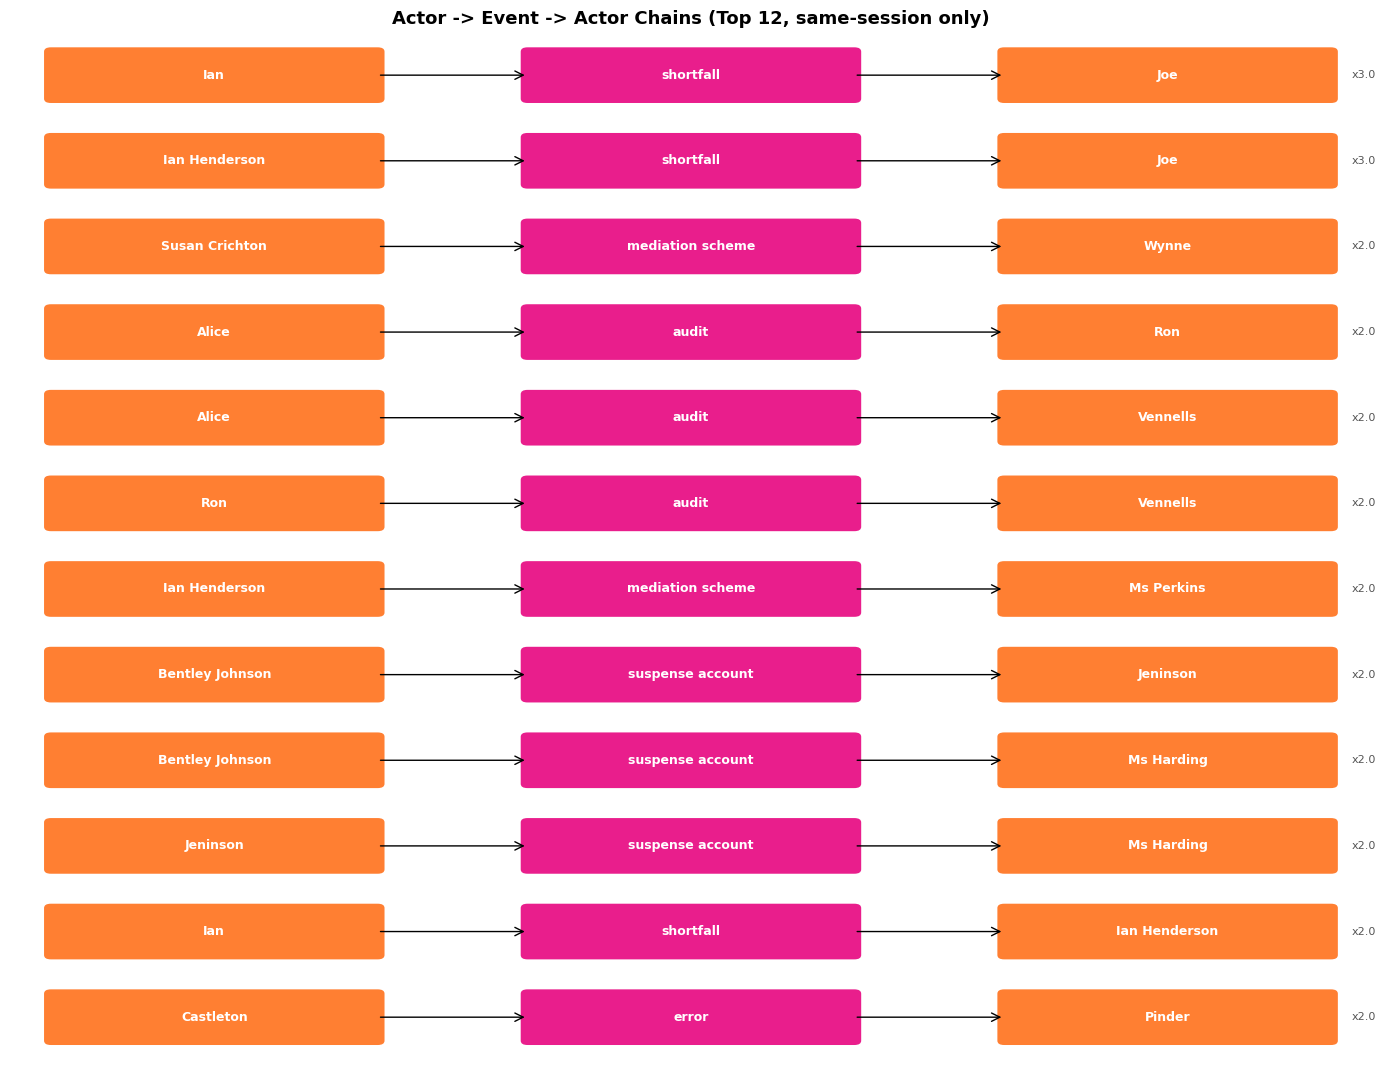

Saved: actor_event_actor_chains_same_session.png


In [86]:
#  Plot Actor -> Event -> Actor Chains


import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

TOP_N = min(12, len(chains_df))

if TOP_N == 0:
    print("No chains to plot.")
else:
    top_chains = chains_df.head(TOP_N).reset_index(drop=True)
    fig, ax = plt.subplots(figsize=(14, max(5, TOP_N * 0.9)))
    ax.set_xlim(0, 10)
    ax.set_ylim(0, TOP_N)
    ax.axis("off")

    box_w, box_h = 2.4, 0.55
    x1, x_ev, x2 = 0.3, 3.8, 7.3   # x-positions: actor1, event, actor2

    ACTOR_COLOUR = "#FF7F32"   # orange
    EVENT_COLOUR = "#E91E8C"   # pink/magenta

    for i, row in top_chains.iterrows():
        y = TOP_N - i - 0.5   # top row = highest strength

        # Actor 1 box
        ax.add_patch(FancyBboxPatch((x1, y - box_h/2), box_w, box_h,
                     boxstyle="round,pad=0.05", facecolor=ACTOR_COLOUR,
                     edgecolor="none"))
        ax.text(x1 + box_w/2, y, row["actor1"], ha="center", va="center",
                color="white", fontsize=9, fontweight="bold")

        # Event box
        ax.add_patch(FancyBboxPatch((x_ev, y - box_h/2), box_w, box_h,
                     boxstyle="round,pad=0.05", facecolor=EVENT_COLOUR,
                     edgecolor="none"))
        ax.text(x_ev + box_w/2, y, row["event"], ha="center", va="center",
                color="white", fontsize=9, fontweight="bold")

        # Actor 2 box
        ax.add_patch(FancyBboxPatch((x2, y - box_h/2), box_w, box_h,
                     boxstyle="round,pad=0.05", facecolor=ACTOR_COLOUR,
                     edgecolor="none"))
        ax.text(x2 + box_w/2, y, row["actor2"], ha="center", va="center",
                color="white", fontsize=9, fontweight="bold")

        # Arrows
        ax.add_patch(FancyArrowPatch((x1 + box_w, y), (x_ev, y),
                     arrowstyle="->", color="black", mutation_scale=15))
        ax.add_patch(FancyArrowPatch((x_ev + box_w, y), (x2, y),
                     arrowstyle="->", color="black", mutation_scale=15))

        # Strength label
        ax.text(x2 + box_w + 0.15, y, f'x{row["strength"]:.1f}',
                ha="left", va="center", fontsize=8, color="#555")

    ax.set_title(f"Actor -> Event -> Actor Chains (Top {TOP_N}, same-session only)",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("actor_event_actor_chains_same_session.png", dpi=200,
                facecolor="white", bbox_inches="tight")
    plt.show()
    print("Saved: actor_event_actor_chains_same_session.png")

In [42]:
# Directed relations, displayed as [Source] - (relation) -> [Target]
rel_df_display = pd.read_csv("directed_relations_clean.csv")

rel_df_display["relation_formatted"] = rel_df_display.apply(
    lambda r: f"[{r['source']}] - ({r['relation']}{' NEGATED' if r['negated'] else ''}) -> [{r['target']}]",
    axis=1
)

table = rel_df_display[["session", "relation_formatted", "sentence"]].copy()
table.columns = ["Session", "Relation", "Evidence (sentence excerpt)"]
table["Evidence (sentence excerpt)"] = table["Evidence (sentence excerpt)"].str[:160] + "..."

pd.set_option("display.max_colwidth", 200)
display(table)

table.to_csv("directed_relations_table.csv", index=False)
print("\nSaved: directed_relations_table.csv")


,Session,Relation,Evidence (sentence excerpt)
0,Day143,[Chair] - (raise) -> [Sue],"concerned, and so I, you know, if a chairman raises issues like this, I wanted to know what had arisen...."
1,Day143,[the system] - (cause) -> [Horizon],"The sample needs to cover cases where defendants claim they didn't take any cash, where assertions have been made that the system, i.e., Horizon, caused the sho..."
2,Day152,[Horizon] - (generate) -> [shortfall],"Well, very much along the lines of what Mr Henderson said that it was very clear that Post Office knew, insofar as a corporation can know anything, the people a..."
3,Day152,[Post Office] - (instruct) -> [Mr Jenkins],"There's evidence that the inquiry has that in autumn 2013, specifically September, the Post Office lawyers knew that there was at least a serious issue as to wh..."
4,Day156,[Horizon] - (fail) -> [suspense account],"They suspect this is because the Horizon system, despite the suspense account entry, failed to recognise the entry on the daily snapshots...."
5,Day156,[error] - (show) -> [Alan],"Also, such error should show up as part of the balancing process...."
6,Day156,[the system] - (record) -> [Software],I'd expect the system to record details of all software updates....



Saved: directed_relations_table.csv


## 20. Betweenness Centrality (Broker Analysis)

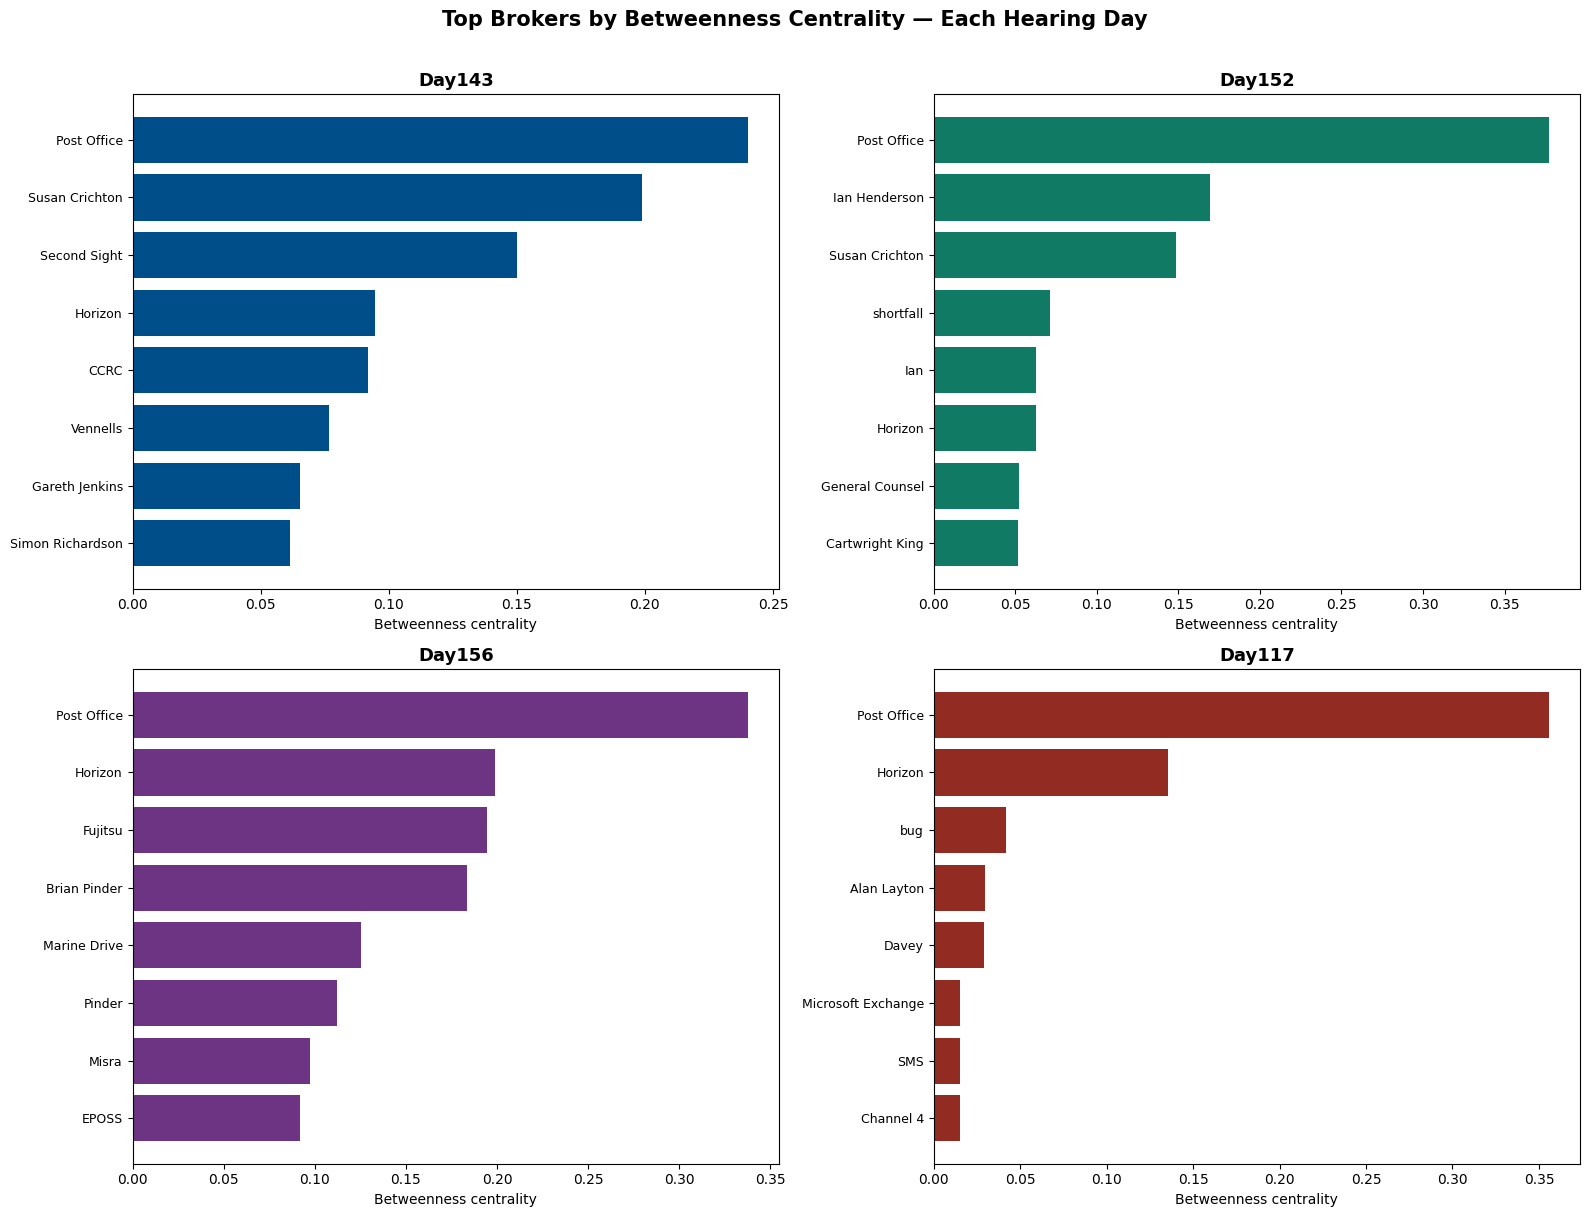

Saved: betweenness_all_days_side_by_side.png


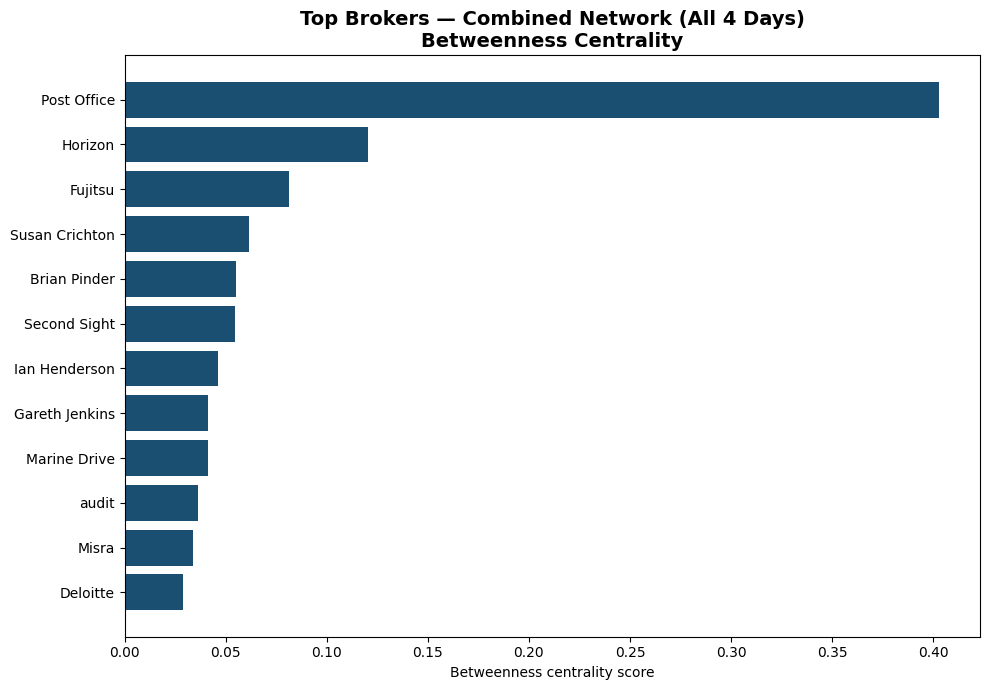

Saved: betweenness_combined.png
Saved: betweenness_summary_table.csv


,Session,Rank,Entity,Betweenness
0,Day143,1,Post Office,0.2403
1,Day143,2,Susan Crichton,0.1989
2,Day143,3,Second Sight,0.1499
3,Day143,4,Horizon,0.0948
4,Day143,5,CCRC,0.0918
5,Day143,6,Vennells,0.0766
6,Day143,7,Gareth Jenkins,0.0654
7,Day143,8,Simon Richardson,0.0613
8,Day152,1,Post Office,0.3774
9,Day152,2,Ian Henderson,0.1693


In [87]:
bc_results = {}
for session in NETWORK_SESSIONS:
    G = graphs[session]
    bc = nx.betweenness_centrality(G, weight="weight")
    bc_results[session] = sorted(bc.items(), key=lambda x: -x[1])[:8]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()
colors = ["#004E89", "#117A65", "#6C3483", "#922B21"]

for i, session in enumerate(NETWORK_SESSIONS):
    top = bc_results[session]
    names = [b[0] for b in top][::-1]
    scores = [b[1] for b in top][::-1]
    ax = axes[i]
    ax.barh(names, scores, color=colors[i])
    ax.set_title(f"{session}", fontweight="bold", fontsize=13)
    ax.set_xlabel("Betweenness centrality")
    ax.tick_params(axis="y", labelsize=9)

fig.suptitle("Top Brokers by Betweenness Centrality — Each Hearing Day",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("betweenness_all_days_side_by_side.png", dpi=180, facecolor="white", bbox_inches="tight")
plt.show()
print("Saved: betweenness_all_days_side_by_side.png")

bc_combined = nx.betweenness_centrality(G_combined, weight="weight")
top_combined = sorted(bc_combined.items(), key=lambda x: -x[1])[:12]

names_c = [b[0] for b in top_combined][::-1]
scores_c = [b[1] for b in top_combined][::-1]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(names_c, scores_c, color="#1B4F72")
ax.set_title("Top Brokers — Combined Network (All 4 Days)\nBetweenness Centrality",
             fontweight="bold", fontsize=14)
ax.set_xlabel("Betweenness centrality score")
plt.tight_layout()
plt.savefig("betweenness_combined.png", dpi=180, facecolor="white")
plt.show()
print("Saved: betweenness_combined.png")

rows = []
for session, top in bc_results.items():
    for rank, (name, score) in enumerate(top, 1):
        rows.append({"Session": session, "Rank": rank, "Entity": name, "Betweenness": round(score, 4)})
for rank, (name, score) in enumerate(top_combined, 1):
    rows.append({"Session": "Combined", "Rank": rank, "Entity": name, "Betweenness": round(score, 4)})

bc_table = pd.DataFrame(rows)
bc_table.to_csv("betweenness_summary_table.csv", index=False)
print("Saved: betweenness_summary_table.csv")
display(bc_table.head(20))


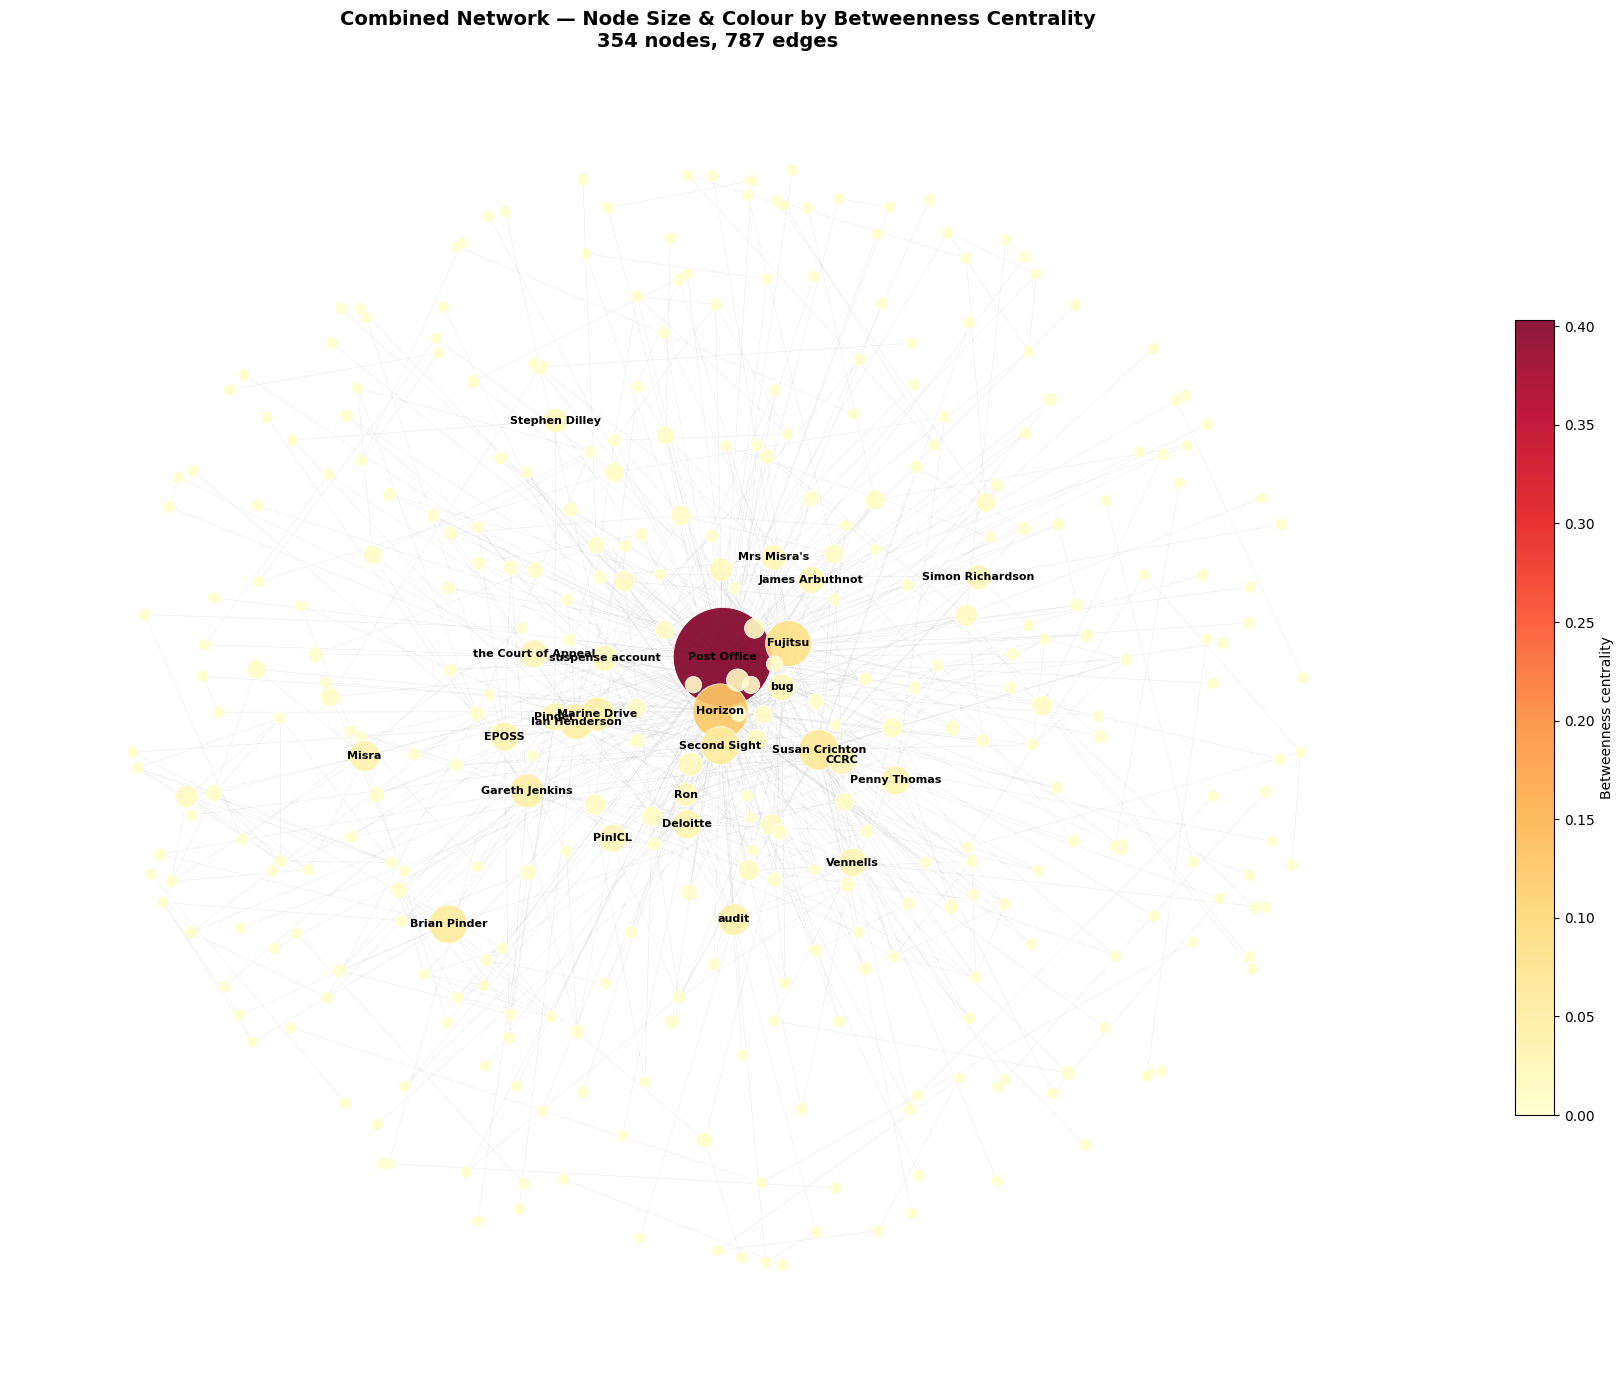

Saved: betweenness_combined_network_graph.png


In [88]:
# Combined network graph betweenness centrality
bc = nx.betweenness_centrality(G_combined, weight="weight")
pos = nx.spring_layout(G_combined, k=1.4, iterations=200, weight="weight", seed=42)

bc_values = np.array([bc[n] for n in G_combined.nodes()])
sizes = 80 + 5000 * (bc_values / (bc_values.max() + 1e-9))

fig, ax = plt.subplots(figsize=(18, 14))
nodes = nx.draw_networkx_nodes(
    G_combined, pos, node_size=sizes, node_color=bc_values, cmap=plt.cm.YlOrRd,
    alpha=0.9, edgecolors="white", linewidths=0.6, ax=ax
)
nx.draw_networkx_edges(G_combined, pos, edge_color="#CCCCCC", width=0.4, alpha=0.4, ax=ax)

threshold = sorted(bc.values(), reverse=True)[min(25, len(bc)-1)]
labels = {n: n for n, v in bc.items() if v >= threshold}
nx.draw_networkx_labels(G_combined, pos, labels=labels, font_size=8, font_weight="bold", ax=ax)

cbar = plt.colorbar(nodes, ax=ax, shrink=0.6, label="Betweenness centrality")
ax.set_title(
    "Combined Network — Node Size & Colour by Betweenness Centrality\n"
    f"{G_combined.number_of_nodes()} nodes, {G_combined.number_of_edges()} edges",
    fontsize=14, fontweight="bold"
)
ax.axis("off")
plt.tight_layout()
plt.savefig("betweenness_combined_network_graph.png", dpi=180, facecolor="white", bbox_inches="tight")
plt.show()
print("Saved: betweenness_combined_network_graph.png")


Entities before filter: 354 | after MIN_MENTIONS=3 filter: 116


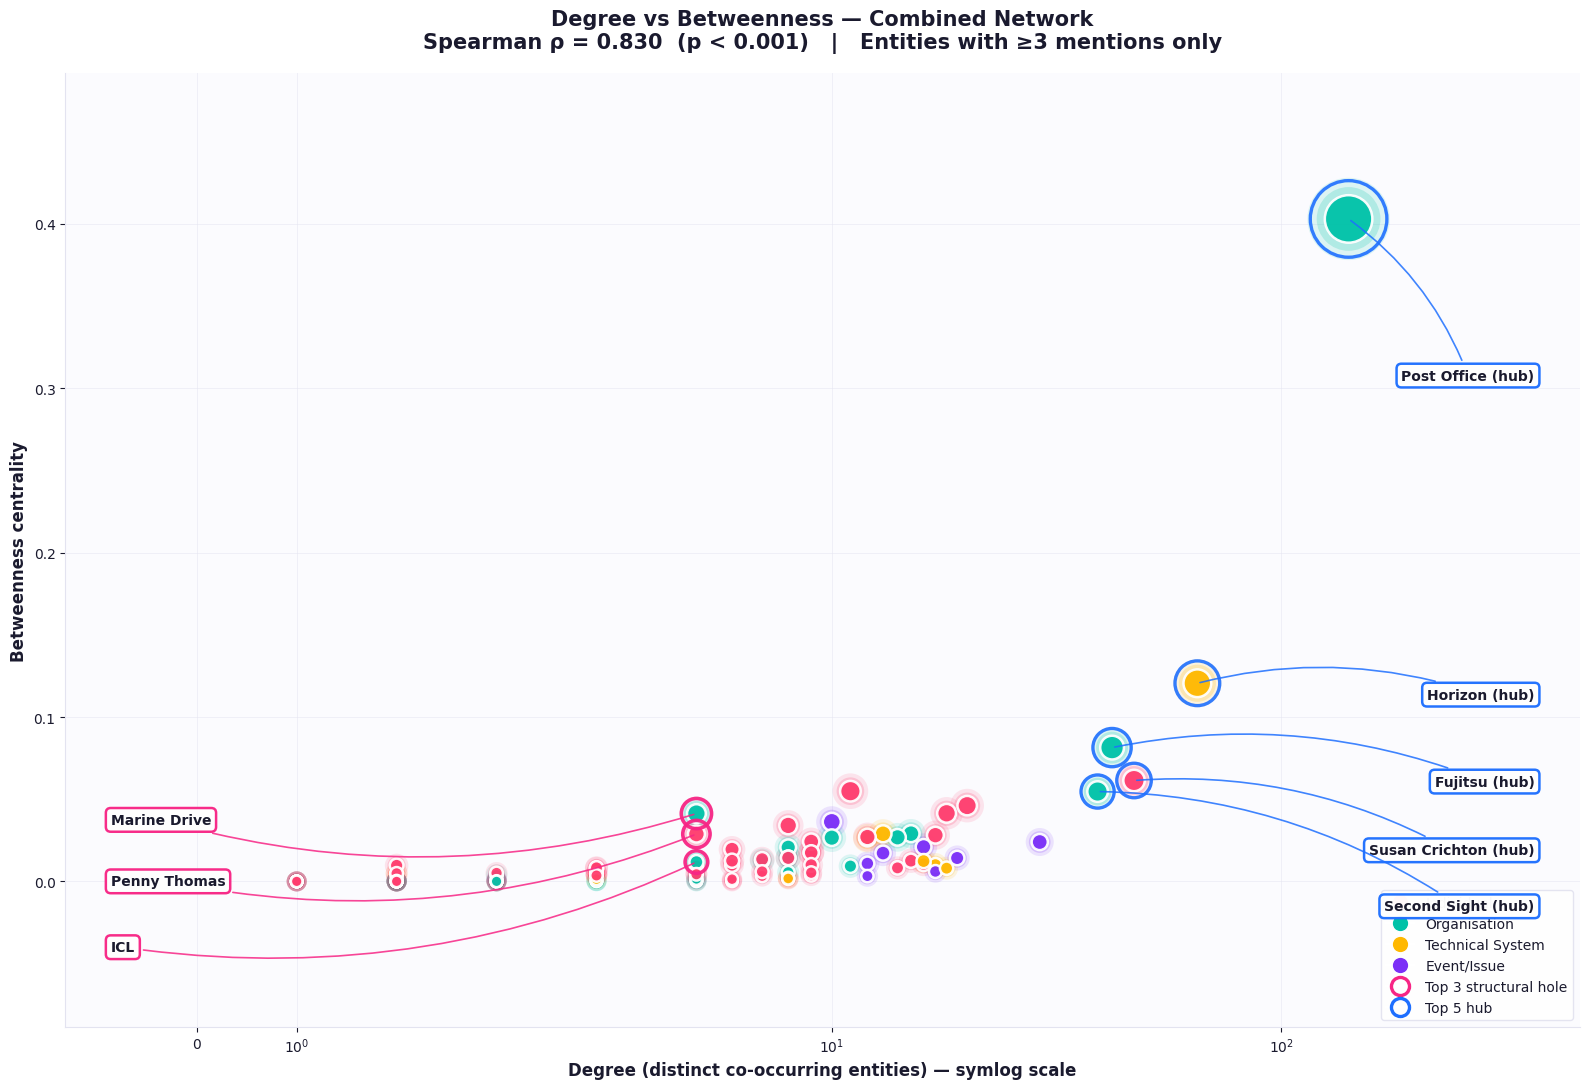

Spearman rho=0.8296, p=1.25e-30
Top 5 hubs: ['Post Office', 'Horizon', 'Susan Crichton', 'Fujitsu', 'Second Sight']
Top 3 structural holes: ['Marine Drive', 'Penny Thomas', 'ICL']


In [91]:
# Degree vs Betweenness — Combined Network 

degrees = dict(G_combined.degree())
bc_combined = nx.betweenness_centrality(G_combined, weight="weight")

nodes = list(G_combined.nodes())

# Filter out low-frequency and noisy entities 
MIN_MENTIONS = 3
mention_counts = combined_entities_df["entity_normalised"].value_counts()
eligible_nodes = set(mention_counts[mention_counts >= MIN_MENTIONS].index)
nodes = [n for n in nodes if n in eligible_nodes]
print(f"Entities before filter: {G_combined.number_of_nodes()} | after MIN_MENTIONS={MIN_MENTIONS} filter: {len(nodes)}")

x = np.array([degrees[n] for n in nodes], dtype=float)
y = np.array([bc_combined[n] for n in nodes], dtype=float)
node_categories = [entity_category_map.get(n, "Unknown") for n in nodes]

rho, pval = spearmanr(x, y)

TOP_N_HUBS = 5
hub_nodes = [n for n, _ in sorted(degrees.items(), key=lambda kv: -kv[1])[:TOP_N_HUBS] if n in eligible_nodes]
is_hub = np.array([n in hub_nodes for n in nodes])

TOP_N_HOLES = 3
non_hub_mask = ~is_hub
nodes_nh = [n for n, h in zip(nodes, is_hub) if not h]
median_degree_nh = np.median(x[non_hub_mask])
candidates = [(n, bc_combined[n]) for n in nodes_nh if degrees[n] <= median_degree_nh]
structural_holes = [n for n, _ in sorted(candidates, key=lambda kv: -kv[1])[:TOP_N_HOLES]]


BG_COLOR = "#FFFFFF"
PANEL_COLOR = "#FBFBFE"
GRID_COLOR = "#E3E3F0"
TEXT_COLOR = "#1A1A2E"

VIVID_CATEGORY_COLOURS = {
    "Individual":        "#FF3D6E",  
    "Organisation":      "#00C2A8",   
    "Technical System":  "#FFB800",   
    "Event/Issue":       "#7B2FF7",   
}
HOLE_COLOUR = "#F72585"      
HUB_COLOUR  = "#1E6FFF"     

point_colors = [VIVID_CATEGORY_COLOURS.get(cat, "#AAAAAA") for cat in node_categories]
size_norm = (y - y.min()) / (y.max() - y.min() + 1e-9)
point_sizes = 70 + 1100 * size_norm

fig, ax = plt.subplots(figsize=(16, 11))
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(PANEL_COLOR)
ax.set_xscale("symlog", linthresh=5)


ax.scatter(x, y, s=point_sizes * 3.0, c=point_colors, alpha=0.12, linewidths=0, zorder=3)
ax.scatter(x, y, s=point_sizes * 1.8, c=point_colors, alpha=0.20, linewidths=0, zorder=3)
# Crisp main points
ax.scatter(x, y, s=point_sizes, c=point_colors, alpha=0.95,
           edgecolors="white", linewidths=1.8, zorder=4)


for n in hub_nodes:
    ax.scatter(degrees[n], bc_combined[n], s=point_sizes[nodes.index(n)] * 2.6,
               facecolors="none", edgecolors=HUB_COLOUR, linewidths=2.4, alpha=0.9, zorder=5)
for n in structural_holes:
    ax.scatter(degrees[n], bc_combined[n], s=point_sizes[nodes.index(n)] * 2.6,
               facecolors="none", edgecolors=HOLE_COLOUR, linewidths=2.6, alpha=0.95, zorder=5)


def add_stacked_labels(names, colour, side, lane_gap=0.052, tag=""):
    ordered = sorted(names, key=lambda n: -bc_combined[n])  # highest betweenness first
    n_items = len(ordered)
    for i, n in enumerate(ordered):
        dx, dy = degrees[n], bc_combined[n]
        lane_y = min(0.94, dy + lane_gap * (n_items - i) + 0.02)
        label_x_frac = 0.03 if side == "left" else 0.97
        ha = "left" if side == "left" else "right"
        ax.annotate(
            f"{n}{tag}",
            xy=(dx, dy), xycoords="data",
            xytext=(label_x_frac, lane_y), textcoords="axes fraction",
            fontsize=10, fontweight="bold", color=TEXT_COLOR, ha=ha, va="center",
            bbox=dict(boxstyle="round,pad=0.35", facecolor="white",
                      edgecolor=colour, linewidth=1.8, alpha=0.97),
            arrowprops=dict(arrowstyle="-", color=colour, lw=1.2, alpha=0.85,
                            connectionstyle="arc3,rad=0.15"),
            zorder=7
        )

add_stacked_labels(structural_holes, HOLE_COLOUR, side="left")
add_stacked_labels(hub_nodes, HUB_COLOUR, side="right", tag=" (hub)")

ax.margins(x=0.22, y=0.22)


legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markeredgecolor="white",
           markersize=12, label=cat)
    for cat, c in VIVID_CATEGORY_COLOURS.items()
]
legend_elements += [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='none',
           markeredgecolor=HOLE_COLOUR, markeredgewidth=2.4, markersize=13,
           label=f"Top {TOP_N_HOLES} structural hole"),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='none',
           markeredgecolor=HUB_COLOUR, markeredgewidth=2.4, markersize=13,
           label=f"Top {TOP_N_HUBS} hub"),
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=10, frameon=True,
          framealpha=0.95, edgecolor=GRID_COLOR, facecolor="white", labelcolor=TEXT_COLOR)


ax.set_xlabel("Degree (distinct co-occurring entities) — symlog scale",
              fontsize=12, fontweight="bold", color=TEXT_COLOR)
ax.set_ylabel("Betweenness centrality", fontsize=12, fontweight="bold", color=TEXT_COLOR)
ax.set_title(
    "Degree vs Betweenness — Combined Network\n"
    f"Spearman ρ = {rho:.3f}  (p < 0.001)   |   Entities with ≥{MIN_MENTIONS} mentions only",
    fontsize=15, fontweight="bold", color=TEXT_COLOR, pad=18
)

ax.tick_params(colors=TEXT_COLOR, labelsize=10)
for spine in ax.spines.values():
    spine.set_color(GRID_COLOR)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, alpha=0.5, linestyle="-", color=GRID_COLOR, linewidth=0.7)

plt.tight_layout()
plt.savefig("degree_vs_betweenness_scatter.png", dpi=220, facecolor=BG_COLOR, bbox_inches="tight")
plt.show()

print(f"Spearman rho={rho:.4f}, p={pval:.4g}")
print(f"Top {TOP_N_HUBS} hubs: {hub_nodes}")
print(f"Top {TOP_N_HOLES} structural holes: {structural_holes}")

In [92]:
# Summary Spearman correlation + hubs + structural holes

from IPython.display import display

summary_df = pd.DataFrame([
    {"Metric": "Spearman correlation (ρ)", "Value": f"{rho:.3f}"},
    {"Metric": "p-value", "Value": "p < 0.001"},
    {"Metric": "Entities analysed (≥3 mentions)", "Value": f"{len(nodes)}"},
])

display(
    summary_df.style
    .set_caption("Degree vs Betweenness — Correlation Summary")
    .set_table_styles([
        {"selector": "caption", "props": [("font-size", "15px"), ("font-weight", "bold"),
                                           ("color", "#1B4F72"), ("padding", "8px 0")]},
        {"selector": "th", "props": [("background-color", "#1B4F72"), ("color", "white"),
                                      ("padding", "8px"), ("text-align", "left")]},
        {"selector": "td", "props": [("padding", "8px 12px"), ("font-weight", "600")]},
        {"selector": "tr:nth-child(even)", "props": [("background-color", "#EAF2FB")]},
    ])
    .hide(axis="index")
)

rows = [{"Type": "Hub", "Entity": n, "Degree": degrees[n], "Betweenness": round(bc_combined[n], 4)} for n in hub_nodes]
rows += [{"Type": "Structural Hole", "Entity": n, "Degree": degrees[n], "Betweenness": round(bc_combined[n], 4)} for n in structural_holes]
findings_df = pd.DataFrame(rows)

def colour_by_type(row):
    colour = "#E3F2FD; color: #0D47A1" if row["Type"] == "Hub" else "#FCE4EC; color: #AD1457"
    return [f"background-color: {colour}; font-weight: bold;"] * len(row)

display(
    findings_df.style
    .set_caption("Top Hubs and Structural Holes")
    .apply(colour_by_type, axis=1)
    .set_table_styles([
        {"selector": "caption", "props": [("font-size", "15px"), ("font-weight", "bold"),
                                           ("color", "#1B4F72"), ("padding", "8px 0")]},
        {"selector": "th", "props": [("background-color", "#1B4F72"), ("color", "white"),
                                      ("padding", "8px"), ("text-align", "center")]},
        {"selector": "td", "props": [("padding", "8px 12px"), ("text-align", "center")]},
    ])
    .hide(axis="index")
)

Metric,Value
Spearman correlation (ρ),0.830
p-value,p < 0.001
Entities analysed (≥3 mentions),116


Type,Entity,Degree,Betweenness
Hub,Post Office,141,0.403000
Hub,Horizon,65,0.120500
Hub,Susan Crichton,47,0.061400
Hub,Fujitsu,42,0.081400
Hub,Second Sight,39,0.054700
Structural Hole,Marine Drive,5,0.041300
Structural Hole,Penny Thomas,5,0.028800
Structural Hole,ICL,5,0.011800


## 21. Key Entity Mention Counts
Sessions with an official transcript (143,152,156) compare official vs AssemblyAPI cleaned. Day 117 (no official transcript) shows a simple top-10 mentions chart

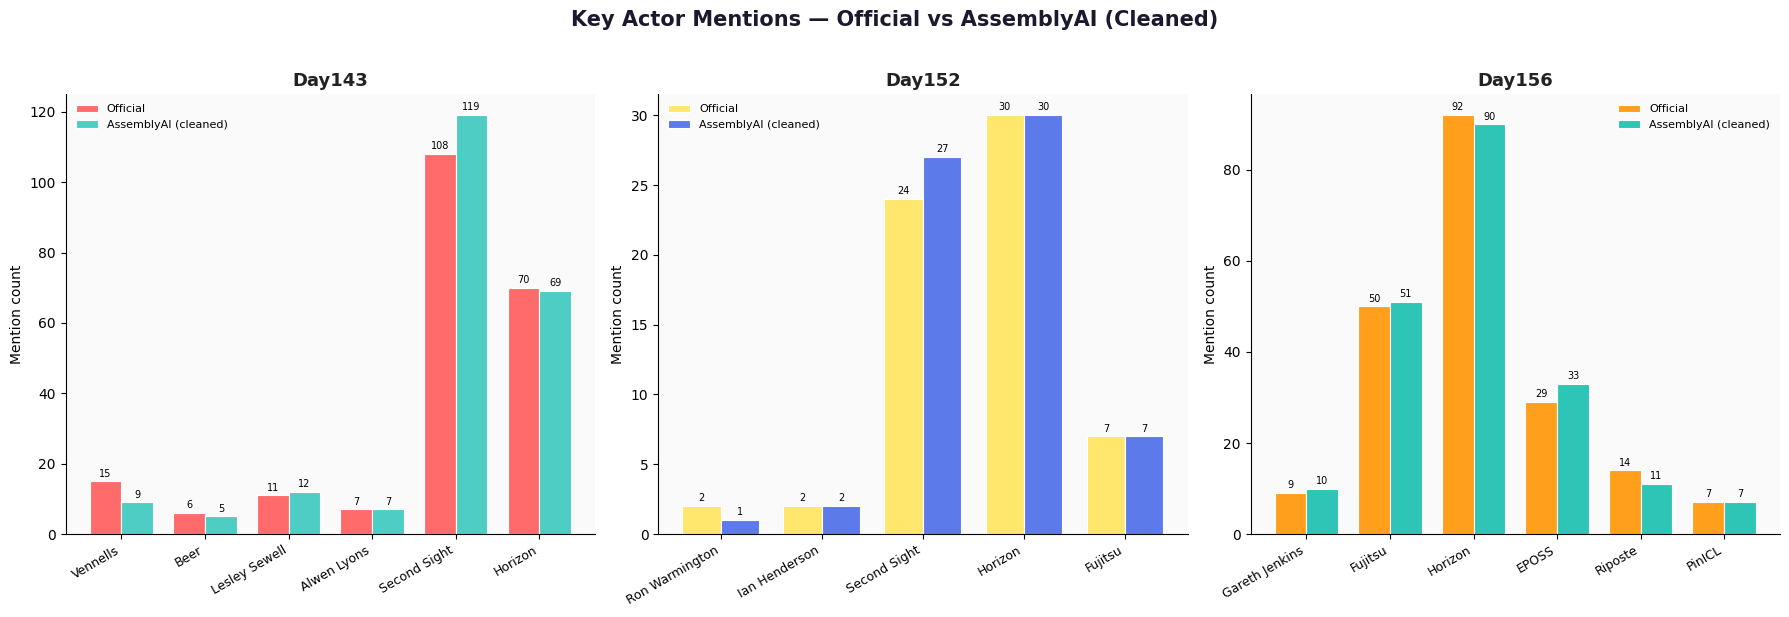

Saved: mention_count_143_152_156_side_by_side.png


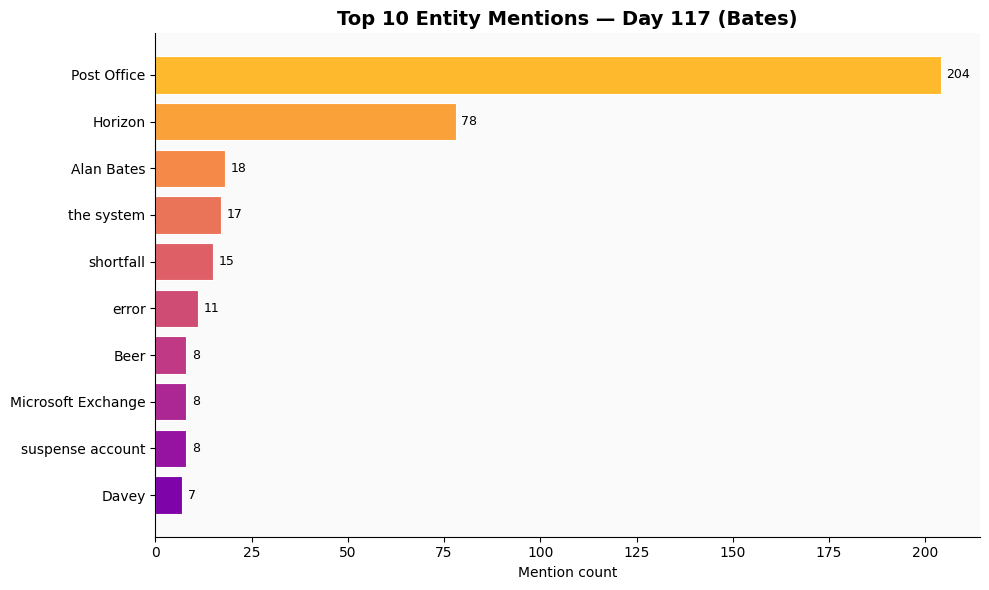

Saved: mention_count_Day117.png


In [93]:
KEY_ACTORS_BY_SESSION = {
    "Day143": ["Vennells", "Beer", "Lesley Sewell", "Alwen Lyons", "Second Sight", "Horizon"],
    "Day152": ["Ron Warmington", "Ian Henderson", "Second Sight", "Horizon", "Fujitsu"],
    "Day156": ["Gareth Jenkins", "Fujitsu", "Horizon", "EPOSS", "Riposte", "PinICL"],
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
session_colors = {
    "Day143": ("#FF6B6B", "#4ECDC4"),
    "Day152": ("#FFE66D", "#5C7AEA"),
    "Day156": ("#FF9F1C", "#2EC4B6"),
}

for ax, session in zip(axes, ["Day143", "Day152", "Day156"]):
    entities = KEY_ACTORS_BY_SESSION[session]
    official_text = cleaned_texts[session]["official"]
    api_clean = cleaned_texts[session]["api"]

    official_counts = [count_mentions(official_text, n) for n in entities]
    api_counts = [count_mentions(api_clean, n) for n in entities]

    x = np.arange(len(entities))
    width = 0.38
    c_off, c_api = session_colors[session]

    bars1 = ax.bar(x - width/2, official_counts, width, label="Official",
                   color=c_off, edgecolor="white", linewidth=0.8)
    bars2 = ax.bar(x + width/2, api_counts, width, label="AssemblyAI (cleaned)",
                   color=c_api, edgecolor="white", linewidth=0.8)

    ax.set_xticks(x)
    ax.set_xticklabels(entities, rotation=30, ha="right", fontsize=9)
    ax.set_ylabel("Mention count", fontsize=10)
    ax.set_title(session, fontweight="bold", fontsize=13, color="#222")
    ax.legend(fontsize=8, frameon=False)
    ax.set_facecolor("#FAFAFA")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.bar_label(bars1, fontsize=7, padding=2)
    ax.bar_label(bars2, fontsize=7, padding=2)

fig.suptitle("Key Actor Mentions — Official vs AssemblyAI (Cleaned)",
             fontsize=15, fontweight="bold", color="#1A1A2E", y=1.02)
plt.tight_layout()
plt.savefig("mention_count_143_152_156_side_by_side.png", dpi=200, facecolor="white", bbox_inches="tight")
plt.show()
print("Saved: mention_count_143_152_156_side_by_side.png")

df = entities_dfs["Day117"]
top = Counter(df["entity_normalised"]).most_common(10)
names = [t[0] for t in top][::-1]
counts = [t[1] for t in top][::-1]

cmap = plt.cm.plasma(np.linspace(0.25, 0.85, len(names)))

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(names, counts, color=cmap, edgecolor="white", linewidth=0.8)
ax.set_title("Top 10 Entity Mentions — Day 117 (Bates)", fontweight="bold", fontsize=14)
ax.set_xlabel("Mention count")
ax.set_facecolor("#FAFAFA")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.bar_label(bars, padding=4, fontsize=9)
plt.tight_layout()
plt.savefig("mention_count_Day117.png", dpi=200, facecolor="white")
plt.show()
print("Saved: mention_count_Day117.png")


## 22. Entity Co-occurrence Heatmaps (Top 10 Entities per Session)


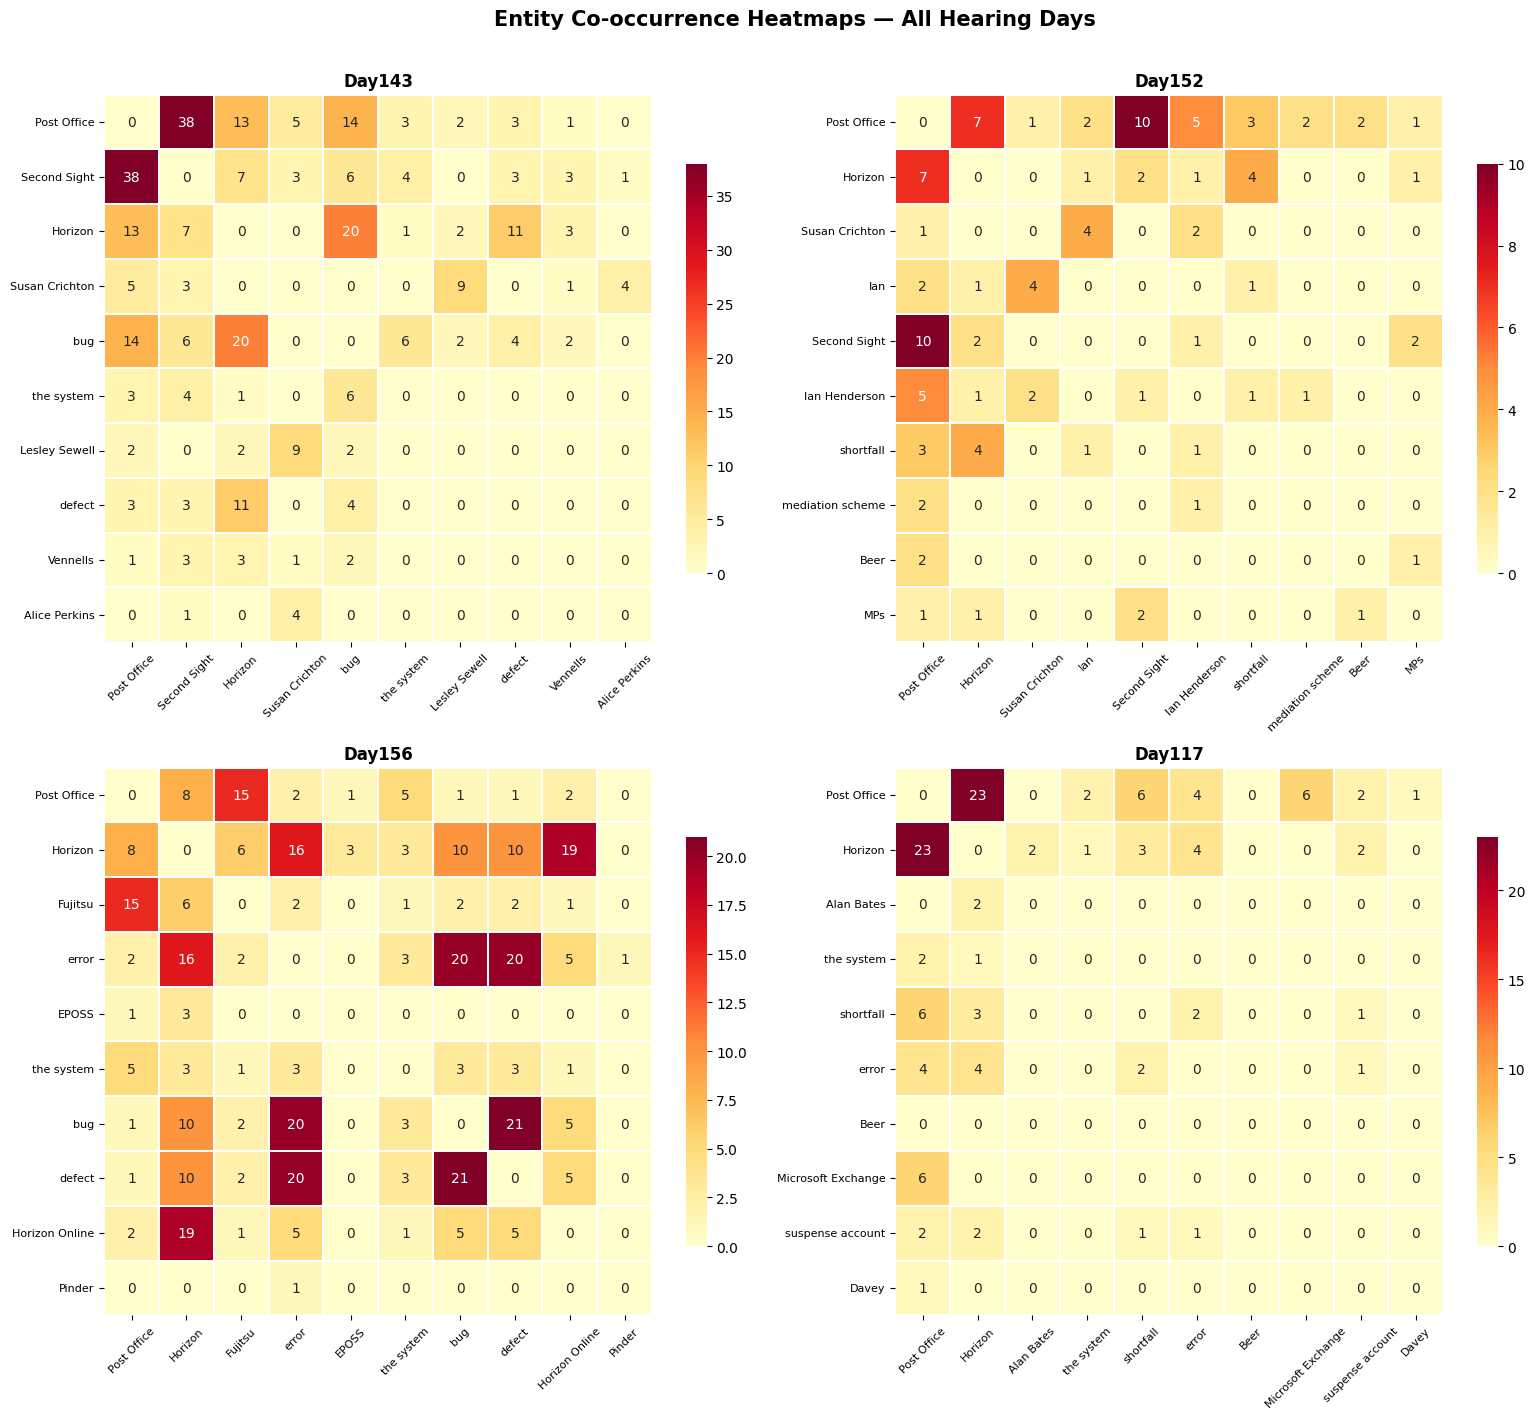

Saved: heatmap_all_days_side_by_side.png


In [94]:
sessions = list(entities_dfs.keys())
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

for ax, session in zip(axes, sessions):
    df = entities_dfs[session]
    top_names = df["entity_normalised"].value_counts().head(10).index.tolist()
    co_matrix = pd.DataFrame(0, index=top_names, columns=top_names)

    for sent_idx, group in df.groupby("sentence_index"):
        present = [e for e in set(group["entity_normalised"]) if e in top_names]
        for a in present:
            for b in present:
                if a != b:
                    co_matrix.loc[a, b] += 1

    sns.heatmap(co_matrix, annot=True, fmt="d", cmap="YlOrRd", square=True,
                linewidths=0.3, linecolor="white", cbar_kws={"shrink": 0.7}, ax=ax)
    ax.set_title(session, fontweight="bold", fontsize=12)
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    ax.tick_params(axis="y", labelsize=8)

fig.suptitle("Entity Co-occurrence Heatmaps — All Hearing Days", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("heatmap_all_days_side_by_side.png", dpi=180, facecolor="white", bbox_inches="tight")
plt.show()
print("Saved: heatmap_all_days_side_by_side.png")


## 23. Entity Mention Timelines -When Key Entities are discussed

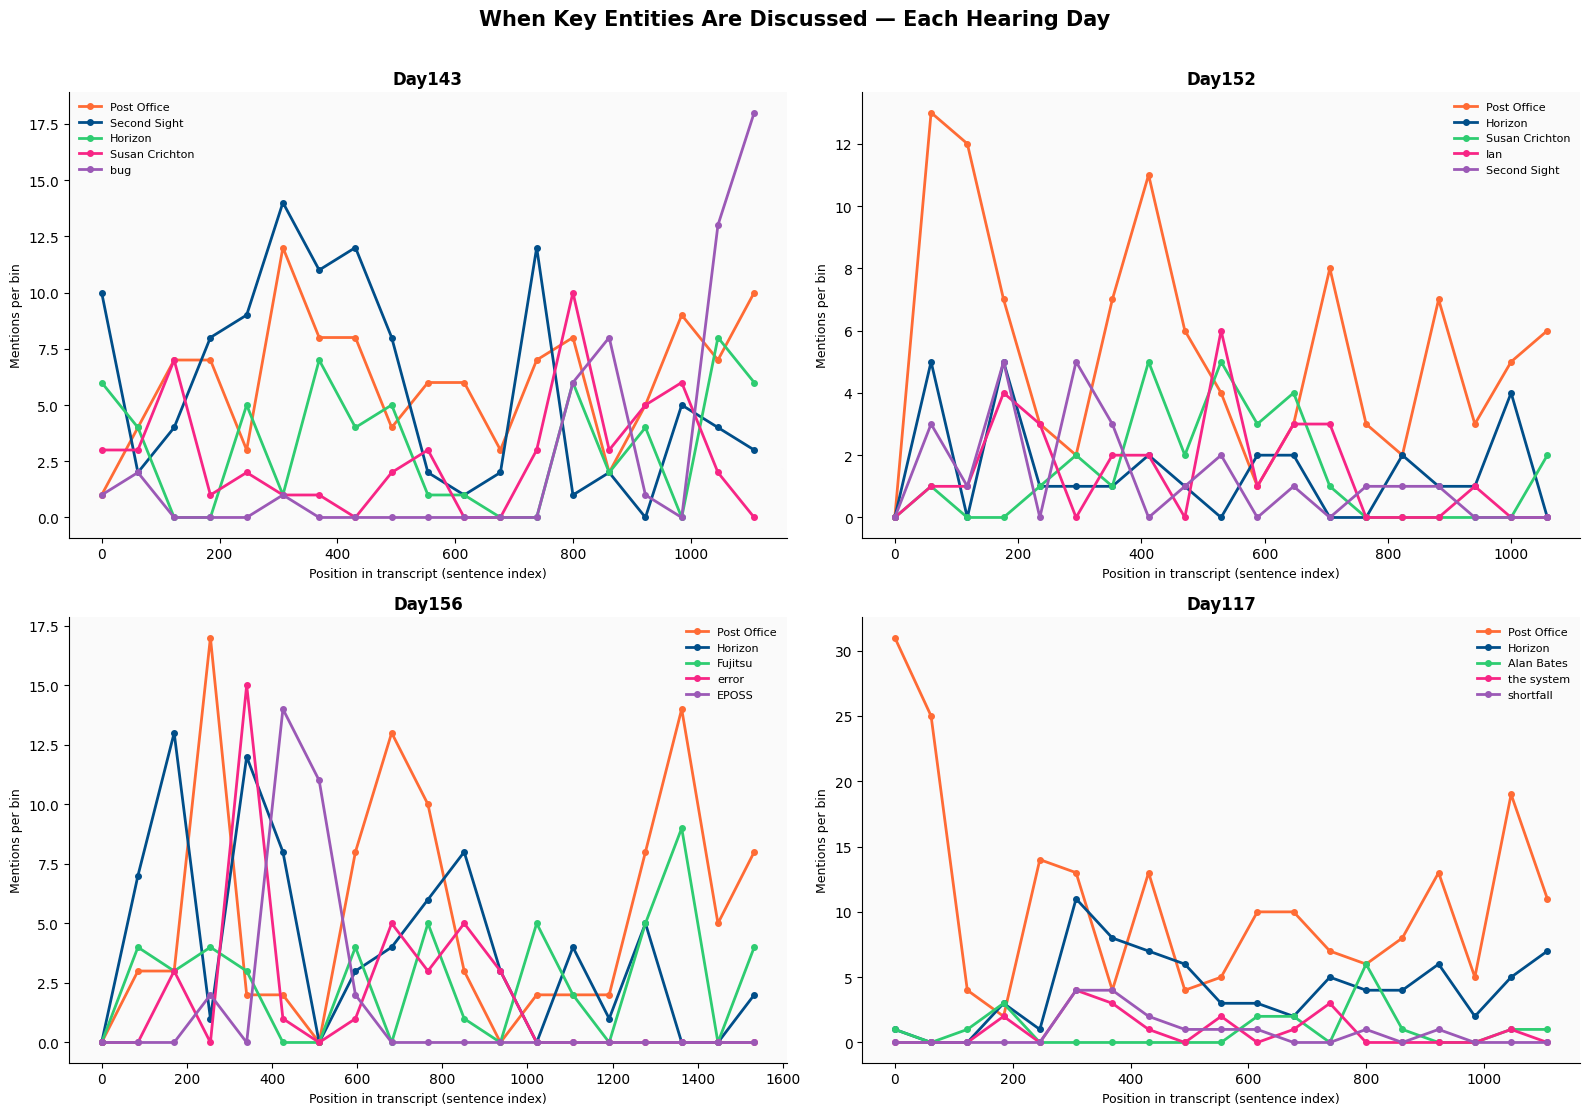

Saved: timeline_all_days_side_by_side.png


In [95]:
COLORS_TIMELINE = ["#FF6B35", "#004E89", "#2ECC71", "#F72585", "#9B59B6"]
sessions = list(entities_dfs.keys())

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
axes = axes.flatten()

for ax, session in zip(axes, sessions):
    df = entities_dfs[session]
    top5 = df["entity_normalised"].value_counts().head(5).index.tolist()
    max_sent = df["sentence_index"].max()
    if max_sent is None or max_sent == 0:
        ax.set_title(f"{session} (no data)")
        continue

    bin_edges = np.linspace(0, max_sent, 20)

    for entity, color in zip(top5, COLORS_TIMELINE):
        sub = df[df["entity_normalised"] == entity]
        counts, _ = np.histogram(sub["sentence_index"], bins=bin_edges)
        ax.plot(bin_edges[:-1], counts, marker="o", markersize=4,
                label=entity, linewidth=2, color=color)

    ax.set_xlabel("Position in transcript (sentence index)", fontsize=9)
    ax.set_ylabel("Mentions per bin", fontsize=9)
    ax.set_title(session, fontweight="bold", fontsize=12)
    ax.legend(fontsize=8, frameon=False)
    ax.set_facecolor("#FAFAFA")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle("When Key Entities Are Discussed — Each Hearing Day", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("timeline_all_days_side_by_side.png", dpi=180, facecolor="white", bbox_inches="tight")
plt.show()
print("Saved: timeline_all_days_side_by_side.png")


## 24. Summary
- Day 143, 152 and 156 -> full pipeline cleaning of dual-pipeline WER Faster-Whisper+Assembly API), NER on both pipelines, network construction and fragility metrics on both pipelines, cross-pipeline agreement testing (Spearman, JAccard), betweenness centrality, mention counts, heatmaps, timelines.
- Day 117 Bates- Assembly API only (no official transcript no Faster-whisper)- cleaning,NER, network, fragility, betweennes, mention counts, heatmap, timeline. No WER, since there is nothing to compare against. Excluded from the cross-pipeline comparison for the same reason.
- Comparative Study (Infected Blood Scandal)-WER Only, as instructed.No NER, no network analysis. Excluded from all cross-session comparisons above. 

## 25 Declaration of AI Use
I have used AI while undertaking my assignment in the following ways:

- To develop research questions on the topic – NO
- To create an outline of the topic – NO
- To explain concepts – YES
- To support my use of language – YES
- To summarise the following articles/resources: NO
- I have used AI to check the grammar errors, flow and layout and take suggestions
from clarity with sentences.